#  AIO 2026 - Kaggle Competition 1 - Hepatic Risk Outcome Prediction 

**Task.** Predict the probability of three possible outcomes for cirrhosis patients:

| Class | Meaning |
|-------|---------|
| `Status_C`  | Patient was alive (censored) at `N_Days` |
| `Status_CL` | Patient was alive at `N_Days` due to a liver transplant |
| `Status_D`  | Patient was deceased at `N_Days` |

**Metric.** Multi-class Log Loss — lower is better. 

---

### Pipeline structure

| Step | Section |
|------|---------|
| 1  | Imports and configuration |
| 2  | Data loading |
| 3  | Structural audit |
| 4  | Exploratory data analysis |
| 5  | Feature matrix construction |
| 6  | Validation strategy (shared Stratified 5-Fold) |
| 7  | Model 1 — Logistic Regression (baseline) |
| 8  | Model 2 — XGBoost |
| 9  | Model 3 — LightGBM |
| 10 | Model 4 — CatBoost |
| 11 | Model comparison |
| 12 | OOF weight-optimised blend |
| 13 | Error analysis |
| 14 | Submission file generation |
| 15 | Experiment evidence for the technical report |


## Step 1 — Imports and Configuration

**Role & Purpose:**
This step is responsible for setting up the execution environment, importing essential libraries, 
and establishing global configuration constants. 

**Workflow:**
* **Centralized Configuration:** All shared constants (such as random seeds and cross-validation fold counts) 
are defined in one place so that modifying a setting affects the entire notebook consistently.
* **Reproducibility Standard:** Fixing `SEED = 42` everywhere is a strict reproducibility requirement, 
ensuring that the technical report allows other researchers to replicate these exact numerical results.
* **Environment Setup:** Installs and imports state-of-the-art machine learning libraries 
(XGBoost, LightGBM, CatBoost) alongside core data science toolkits (pandas, numpy, scikit-learn), and other libraries.

**Expected Objective & Outcome:**
Prepare a fully functional, conflict-free runtime environment and verify library versions, 
ensuring seamless execution for all downstream data pipelines and model training steps.


In [1]:
import warnings
warnings.filterwarnings("ignore") # controls Python's warning messages

# Standard libraries 
import os    
import json
import time   # measures total notebook runtime (Reproducibility section)
import random # seeds Python's built-in RNG, which some sklearn internals rely on 
import sys, sklearn, scipy 

# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer                                   # different transforms per column group
from sklearn.pipeline import Pipeline                                           # keeps every fit inside the training fold
from sklearn.metrics import log_loss, confusion_matrix, ConfusionMatrixDisplay

# Gradient boosting libraries 
# Install the exact boosting-library versions used in this notebook.
# Pinning versions helps make the final results reproducible.
%pip install -q xgboost==3.3.0 lightgbm==4.7.0 catboost==1.2.10
import xgboost as xgb 
import lightgbm as lgb 
import catboost
from catboost import CatBoostClassifier, Pool                                    # Pool declares cat_features to CatBoost

print("Libraries imported successfully.")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  xgboost    {xgb.__version__}")
print(f"  lightgbm   {lgb.__version__}") 
print(f"  catboost   {catboost.__version__}")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.
  numpy      2.3.3
  pandas     2.3.3
  xgboost    3.3.0
  lightgbm   4.7.0
  catboost   1.2.10


In [2]:
# Paths Configuration (Select Approach 1 or 2) 

# APPROACH 1: Google Colab & Google Drive 
# Use this approach during local development and experimentation in Google Colab.
# Uncomment the block below to mount your Drive and load data from your custom folder.

# from google.colab import drive 
# drive.mount('/content/drive')

# Paths to folder Kaggle1_Uyen in Google Drive 
# Define file paths for the training data, testing data, and the directory where output files (submission csv for test data, jupyter notebook, technical report) will be stored.
# For rerunning the notebook in Google Colab, please add the shared Kaggle1_Uyen folder as a shortcut directly under My Drive, then run all cells from top to bottom.
# TRAIN_PATH = "/content/drive/MyDrive/Kaggle1_Uyen/aio26_train.csv"
# TEST_PATH  = "/content/drive/MyDrive/Kaggle1_Uyen/aio26_test.csv"
# OUT_DIR    = "/content/drive/MyDrive/Kaggle1_Uyen/working_dir" 

# APPROACH 2: Kaggle Environment / Local Execution 
# Use this approach when running on Kaggle or when data files reside in the current directory.
TRAIN_PATH = "aio26_train.csv" 
TEST_PATH = "aio26_test.csv" 
OUT_DIR = "working_dir"

# Create Output Directory
# Create the output directory if it doesn't already exist. Creating folder to save result (working_dir). The 'exist_ok=True' argument prevents the code from crashing if the folder is already there.
os.makedirs(OUT_DIR, exist_ok=True)

# Competition constants 
# Specify the name of the target variable we aim to predict and the unique identifier column for each patient.
TARGET  = "Status"
ID_COL  = "id"

# Define the exact order of the target classes. This order must be strictly maintained to ensure the final submission file has the correct column layout (Status_C, Status_CL, Status_D).
CLASSES = ["C", "CL", "D"]

# Validation settings
# N_FOLDS: Set the number of splits for Cross-Validation to evaluate the model's performance reliably.
# SEED: Set a fixed random seed to ensure that our results are completely reproducible across different runs.
N_FOLDS = 5
SEED    = 42

# Column groups
# Define a list of categorical features in the dataset. These columns will require specific preprocessing, such as categorical encoding, before being fed into the machine learning model. 
# Treatment_Assignment, Patient_Sex, Ascites_Indicator, Liver_Enlargement, Spider_Angioma, Edema_Status are nominal categories.
# Clinical_Stage is ordinal, because stage 1 < 2 < 3 < 4 has a natural order. Clinical_Stage is stored as numbers (1–4), but it represents an ordered clinical category rather than a continuous measurement.
# I therefore include it among the categorical features. This avoids forcing a linear and equally spaced effect across stages.
# However, categorical encoding does not explicitly preserve the natural order Stage 1 < Stage 2 < Stage 3 < Stage 4.
CAT_COLS = [
    "Treatment_Assignment",
    "Patient_Sex",
    "Ascites_Indicator",
    "Liver_Enlargement",
    "Spider_Angioma",
    "Edema_Status",
    "Clinical_Stage",
]

# Define a list of features related to a specific clinical trial.
# Missing values in these columns occur together structurally for patients who were never enrolled in the trial (i.e., missing not at random).
TRIAL_BLOCK = [
    "Treatment_Assignment",
    "Ascites_Indicator",
    "Liver_Enlargement",
    "Spider_Angioma",
    "Copper_Level",
    "Alkaline_Phosphatase",
    "AST_Level",
]

# Initialize an empty dictionary to serve as a central registry. This will store Cross-Validation (CV) scores, Out-Of-Fold (OOF) predictions, and test predictions for all experimented models.
RESULTS = {}
RESULTS = {}

# Print a confirmation message displaying the current configuration settings to quickly verify them before the training process begins.
print("Configuration set.")
print(f"  Folds : {N_FOLDS}  |  Seed: {SEED}  |  Classes: {CLASSES}")

Configuration set.
  Folds : 5  |  Seed: 42  |  Classes: ['C', 'CL', 'D']


## Step 2 — Data Loading

**Role & Purpose:**
The primary objective of this step is to ingest the raw training and testing datasets 
into memory while preserving the true semantic meaning of clinical observations.

**Workflow:**
* **Handling the `"None"` String Issue:**

`keep_default_na=False, na_values=[""]`

The column `Edema_Status` contains the literal string `"None"`, which means *no
edema present* — a real clinical observation covering roughly 92% of patients.
With pandas' default settings, that string is silently converted into `NaN` (missing values),
which destroys a legitimate category and inflates the apparent missingness of
the column.

* **Custom Read Options:** By configuring `keep_default_na=False` and setting `na_values=[""]`, 
we prevent pandas from misinterpreting `"None"` as missing data, ensuring that only truly empty 
cells are treated as `NaN` and preserves the original meaning of the data.

**Expected Objective & Outcome:**
Successfully load the tabular datasets into clean pandas DataFrames, verify their structural dimensions 
(rows and columns), and perform initial visual inspection without corrupting clinical categories.

In [3]:
# Define a dictionary for custom read options. 
# keep_default_na=False: Prevents pandas from automatically converting the literal string "None" (a valid clinical observation for Edema) into NaN.
# na_values=[""]: Explicitly instructs pandas to only treat completely empty cells as missing values (NaN).
read_opts = dict(keep_default_na=False, na_values=[""])

# Load the training dataset using the predefined path and unpack the custom read options using **
train = pd.read_csv(TRAIN_PATH, **read_opts) 
# Load the testing dataset using the predefined path and the same custom read options
test  = pd.read_csv(TEST_PATH,  **read_opts)

# Print the shape (number of rows and columns) of the training dataset. The ':, ' formats numbers with thousand separators.
print(f"Train : {train.shape[0]:,} rows x {train.shape[1]} columns") 

# Print the shape (number of rows and columns) of the testing dataset 
print(f"Test  : {test.shape[0]:,} rows x {test.shape[1]} columns") 

# Print an empty line for better visual formatting in the output
print() 

# Display the first 5 rows of the training dataset to visually inspect the loaded data
train.head()

Train : 12,000 rows x 20 columns
Test  : 10,000 rows x 19 columns



,id,Followup_Days,Treatment_Assignment,Patient_Age_Days,Patient_Sex,Ascites_Indicator,Liver_Enlargement,Spider_Angioma,Edema_Status,Bilirubin_Level,Cholesterol_Level,Albumin_Level,Copper_Level,Alkaline_Phosphatase,AST_Level,Triglyceride_Level,Platelet_Count,Prothrombin_Time,Clinical_Stage,Status
0,7523,1416,Treatment_A,26612,Female,Absent,Absent,Absent,Controlled,0.50,NaN,3.517,15.1,726.3,83.97,NaN,258.2,9.87,2.0,C
1,10266,3182,Treatment_A,18647,Female,Absent,Absent,Absent,None,0.55,224.8,4.087,30.0,669.6,58.56,65.6,272.0,10.55,3.0,C
2,9705,1372,NaN,23408,Female,NaN,NaN,NaN,None,0.82,NaN,3.789,NaN,NaN,NaN,NaN,388.8,9.94,3.0,C
3,961,2077,NaN,27398,Female,NaN,NaN,NaN,None,0.90,NaN,3.095,NaN,NaN,NaN,NaN,NaN,10.50,4.0,C
4,3535,1121,NaN,18580,Female,NaN,NaN,NaN,None,0.80,NaN,3.093,NaN,NaN,NaN,NaN,189.4,10.85,3.0,D


In [4]:
# Target distribution and column types
# Print a header for the target distribution section
print("TARGET DISTRIBUTION") 

# Print a dashed line separator for visual clarity
print("-" * 40) 

# Calculate the frequency of each class in the target column and reorder the index to strictly match the predefined CLASSES list 
counts = train[TARGET].value_counts().reindex(CLASSES) 

# Iterate through the calculated class counts (cls = class name, cnt = count) 
for cls, cnt in counts.items(): 
    # Calculate the percentage of the current class relative to the total number of rows in the training data
    pct = cnt / len(train) * 100 

    # Print the formatted statistics: class name (left-aligned), raw count, and percentage (rounded to 2 decimal places)
    print(f"  Status {cls:<3s}: {cnt:5d}  ({pct:5.2f}%)")

# Count the total number of columns that contain numerical data types (e.g., int, float)
n_num = train.select_dtypes(include="number").shape[1] 

# Count the total number of columns that contain object data types (e.g., strings, categorical data) 
n_obj = train.select_dtypes(include="object").shape[1] 

# Print an empty line for better visual formatting 
print() 

# Print the total count of numeric columns 
print(f"Numeric columns     : {n_num}") 

# Print the total count of object (categorical) columns 
print(f"Object columns      : {n_obj}") 

# Check which columns have missing values (isnull().any()), sum the True boolean values, and print the total number of columns containing NaNs 
print(f"Columns with any NaN: {train.isnull().any().sum()}")

TARGET DISTRIBUTION
----------------------------------------
  Status C  :  8151  (67.92%)
  Status CL :   317  ( 2.64%)
  Status D  :  3532  (29.43%)

Numeric columns     : 13
Object columns      : 7
Columns with any NaN: 11


## Step 3 — Structural Data Audit
**Role & purpose:**
Before I start building any models, I run a quick health check on the datasets. This audit acts as a safety net against silent data bugs—errors that won't crash the code but will silently ruin the predictions. 

**Workflow:**
In this quick check, I will verify:
*   The target column only contains the exactly expected three classes.
*   The `train` and `test` datasets share the exact same feature columns.
*   There are no duplicated patient IDs in either dataset.
*   Our categorical mapping is clean and ready for the final submission.

**Expected Objective & Outcome:**
Running this check upfront ensures my modeling pipeline is built on a solid foundation.

In [5]:
# Print visual separators for a clean output display 
print("=" * 62)
print("STRUCTURAL AUDIT")
print("=" * 62)

# 3.1  Target classes
# Extract the unique values actually present in the training target column and sort them
observed = sorted(train[TARGET].unique())
print("\n3.1  Target classes")
print(f"     Observed in data : {observed}")
print(f"     Configured order : {CLASSES}") 
# Use Python 'set' to compare the two lists. Sets don't care about order, 
# they just check if the exact same elements exist in both.
print(f"     Match            : {set(observed) == set(CLASSES)}") 
# Dynamically generate the required submission column names based on our CLASSES list 
print(f"     Submission cols  : {[f'Status_{c}' for c in CLASSES]}")

# 3.2  Feature alignment between train and test
# Convert column names into sets to easily find differences using mathematical subtraction.
# I removed the TARGET and ID_COL from the train features so we only compare actual predictors.
train_feats = set(train.columns) - {TARGET, ID_COL}
test_feats  = set(test.columns)  - {ID_COL} 

# Find columns that exist in one dataset but are missing from the other
only_train  = train_feats - test_feats
only_test   = test_feats  - train_feats

print("\n3.2  Feature alignment") 
# Check how many features both datasets have in common using the intersection operator (&)
print(f"     Shared features    : {len(train_feats & test_feats)}")
print(f"     Train-only columns : {sorted(only_train) if only_train else 'none'}")
print(f"     Test-only columns  : {sorted(only_test)  if only_test  else 'none'}")

# 3.3  Duplicate identifiers (IDs) 
print("\n3.3  Duplicate IDs") 
# count how many rows have an ID that has already appeared above it 
print(f"     Train : {train[ID_COL].duplicated().sum()}")
print(f"     Test  : {test[ID_COL].duplicated().sum()}")

# 3.4  Target encoding sanity check
# The .map() function tries to convert our string classes ('C', 'CL', 'D') into numbers (0, 1, 2).
# If it finds a weird string that isn't in our dictionary, it will output a NaN (Not a Number).
y_check = train[TARGET].map({c: i for i, c in enumerate(CLASSES)}) 

print("\n3.4  Target encoding  (C -> 0, CL -> 1, D -> 2)") 
# We sum the NaNs to ensure every single row was successfully converted to a number. 
print(f"     Unmapped values : {int(y_check.isna().sum())}   (must be 0)")

# 3.5  Categorical level consistency
print("\n3.5  Categorical levels: present in test but never seen in train")
unseen_found = False 

# Loop through every categorical feature to check for 'data drift' (new categories appearing in test)
for col in CAT_COLS:
    if col in test.columns: 
        # Get unique categories in test and subtract unique categories in train
        unseen = set(test[col].dropna().unique()) - set(train[col].dropna().unique()) 

        # If the resulting set is not empty, it means we found a new category
        if unseen:
            print(f"     {col}: {sorted(unseen)}")
            unseen_found = True 

# If the loop finishes without finding any new categories, print a success message
if not unseen_found:
    print("     None — every test category also appears in train.")

print("\n" + "=" * 62)
print("Audit complete.")
print("=" * 62)

STRUCTURAL AUDIT

3.1  Target classes
     Observed in data : ['C', 'CL', 'D']
     Configured order : ['C', 'CL', 'D']
     Match            : True
     Submission cols  : ['Status_C', 'Status_CL', 'Status_D']

3.2  Feature alignment
     Shared features    : 18
     Train-only columns : none
     Test-only columns  : none

3.3  Duplicate IDs
     Train : 0
     Test  : 0

3.4  Target encoding  (C -> 0, CL -> 1, D -> 2)
     Unmapped values : 0   (must be 0)

3.5  Categorical levels: present in test but never seen in train
     None — every test category also appears in train.

Audit complete.


## Step 4 — Exploratory Data Analysis
**Role & Purpose:**
Answer all questions addressed in this section:

1. Is the target imbalanced, and what does that imply for validation?
2. Which columns have substantial missingness?
3. Does missingness differ across target classes — is it informative?
4. Do numeric features separate the classes?
5. Are categorical features associated with the outcome?
6. Are the train and test distributions broadly similar?

**Workflow:**
Each code block answers a question and ends with an **Observation** block (comments about the outputs).

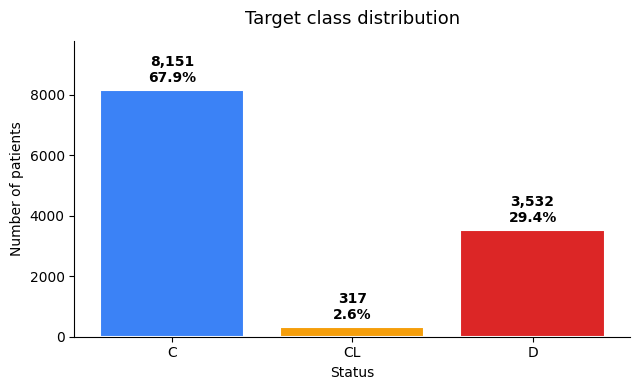

OBSERVATION
--------------------------------------------------------------
The classes are imbalanced. The rarest class holds 2.6% of rows.
A plain random split could therefore produce folds with very few — or in the
worst case zero — examples of the minority class, making validation unstable.

DECISION -> use StratifiedKFold so every fold preserves the class proportions.


In [6]:
# 4.1  Target class distribution 
# Create a figure and axis object with a specific size (6.5 inches wide, 4 inches tall)
fig, ax = plt.subplots(figsize=(6.5, 4))

# Count the occurrences of each class and ensure they are ordered according to our CLASSES list
counts  = train[TARGET].value_counts().reindex(CLASSES) 
# Define specific hex colors for each class to keep charts visually consistent
palette = ["#3b82f6", "#f59e0b", "#dc2626"] 
# Create a bar chart with the counts, applying the custom colors and white borders
bars    = ax.bar(counts.index, counts.values, color=palette,
                 edgecolor="white", linewidth=1.5)

# Loop through each bar to add text labels on top of them
for bar, cnt in zip(bars, counts.values): 
    # Calculate the percentage of this class out of the total dataset
    pct = cnt / len(train) * 100 
    # Place text (count and percentage) slightly above each bar, centered horizontally
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.02,
            f"{cnt:,}\n{pct:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# Add title, axis labels, and adjust the layout for a clean look
ax.set_title("Target class distribution", fontsize=13, pad=12)
ax.set_xlabel("Status"); ax.set_ylabel("Number of patients")
ax.set_ylim(0, counts.max() * 1.20) 
# Hide the top and right borders (spines) of the chart to make it look modern
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# Calculate the percentage of the rarest class to highlight the imbalance
minority_pct = counts.min() / len(train) * 100
print("OBSERVATION")
print("-" * 62)
print(f"The classes are imbalanced. The rarest class holds {minority_pct:.1f}% of rows.")
print("A plain random split could therefore produce folds with very few — or in the")
print("worst case zero — examples of the minority class, making validation unstable.")
print()
print("DECISION -> use StratifiedKFold so every fold preserves the class proportions.")

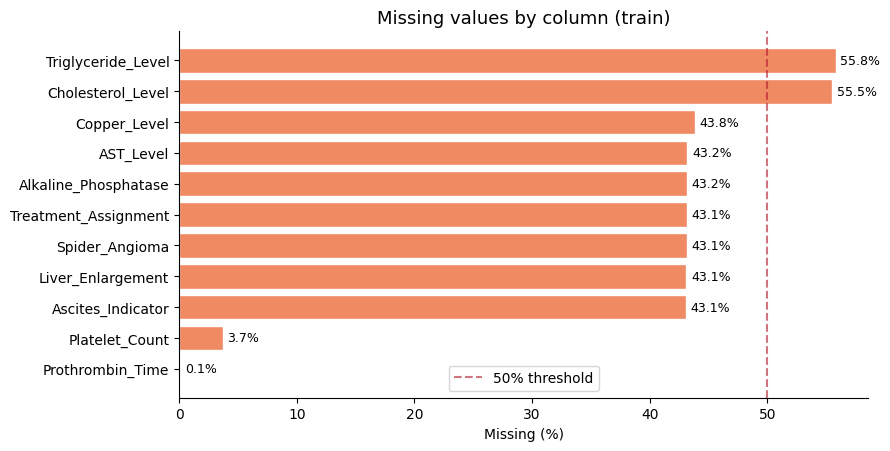

OBSERVATION
--------------------------------------------------------------
  Triglyceride_Level        55.8%  <- above 50%
  Cholesterol_Level         55.5%  <- above 50%
  Copper_Level              43.8%
  AST_Level                 43.2%
  Alkaline_Phosphatase      43.2%
  Treatment_Assignment      43.1%
  Spider_Angioma            43.1%
  Liver_Enlargement         43.1%
  Ascites_Indicator         43.1%
  Platelet_Count             3.7%
  Prothrombin_Time           0.1%

A common first reflex is to drop columns above 50% missing. Before doing so,
the next cell asks a more useful question: is the missingness itself
informative about the outcome?


In [7]:
# 4.2  Missing-value overview 
# Calculate the percentage of missing values (NaN) for every column in the dataset 
missing_pct = (train.isnull().mean() * 100) 
# Filter out columns that have 0 missing values, and sort the rest in descending order 
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Dynamically adjust the height of the chart based on how many columns have missing data 
fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(missing_pct)))) 
# Create a horizontal bar chart (barh) to display missing percentages 
bars = ax.barh(missing_pct.index, missing_pct.values,
               color="#ef8a62", edgecolor="white")

# Add the exact percentage text to the right of each horizontal bar
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

# Draw a vertical dashed line at the 50% mark as a visual reference threshold 
ax.axvline(50, color="#b2182b", linestyle="--", alpha=0.6, label="50% threshold")
ax.set_title("Missing values by column (train)", fontsize=13)
ax.set_xlabel("Missing (%)") 
# Invert the y-axis so the column with the most missing data appears at the top
ax.invert_yaxis(); ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("OBSERVATION")
print("-" * 62) 
# Print a text-based summary, flagging any column that exceeds the 50% missing threshold
for col, pct in missing_pct.items():
    flag = "  <- above 50%" if pct > 50 else ""
    print(f"  {col:<24s} {pct:5.1f}%{flag}")
print()
print("A common first reflex is to drop columns above 50% missing. Before doing so,")
print("the next cell asks a more useful question: is the missingness itself")
print("informative about the outcome?")

In [8]:
# 4.3  Does missingness differ across target classes? 
print("MISSINGNESS RATE BY TARGET CLASS (%)")
print("=" * 62)

# Create an empty list to store the missingness data for our summary table 
miss_table = [] 
# Loop through only the columns that actually have missing values 
for col in missing_pct.index:
    row = {"Feature": col} 
    # Group the data by target class, then calculate the missing percentage for this specific column within each group
    by_class = train.groupby(TARGET)[col].apply(lambda s: s.isnull().mean() * 100) 

    # Store the missing percentage for 'C', 'CL', and 'D' respectively
    for cls in CLASSES:
        row[f"Status_{cls}"] = round(by_class.get(cls, 0.0), 1) 

    # Calculate the 'Spread' (difference between the maximum and minimum missing rate across the classes)
    row["Spread"] = round(max(row[f"Status_{c}"] for c in CLASSES)
                          - min(row[f"Status_{c}"] for c in CLASSES), 1)
    miss_table.append(row)

# Convert the list of dictionaries into a pandas DataFrame and sort by the widest spread first 
miss_df = pd.DataFrame(miss_table).sort_values("Spread", ascending=False)
print(miss_df.to_string(index=False))

print()
print("OBSERVATION")
print("-" * 62)
print("'Spread' is the gap between the highest and lowest missingness rate across")
print("classes. A large spread means the fact that a value is missing carries signal:")
print("it is correlated with the outcome rather than occurring at random.")
print()
print("DECISION -> impute, but also add binary missing-indicator columns so the model")
print("            can still see which values were originally absent.")

MISSINGNESS RATE BY TARGET CLASS (%)
             Feature  Status_C  Status_CL  Status_D  Spread
   Cholesterol_Level      55.1       46.1      57.2    11.1
  Triglyceride_Level      55.4       46.7      57.6    10.9
        Copper_Level      43.3       38.8      45.5     6.7
   Ascites_Indicator      42.7       38.5      44.4     5.9
           AST_Level      42.8       38.8      44.5     5.7
Alkaline_Phosphatase      42.8       38.8      44.5     5.7
      Spider_Angioma      42.7       38.8      44.5     5.7
Treatment_Assignment      42.8       38.8      44.4     5.6
   Liver_Enlargement      42.7       38.8      44.3     5.5
      Platelet_Count       3.5        0.6       4.4     3.8
    Prothrombin_Time       0.1        0.0       0.2     0.2

OBSERVATION
--------------------------------------------------------------
'Spread' is the gap between the highest and lowest missingness rate across
classes. A large spread means the fact that a value is missing carries signal:
it is correla

In [9]:
# 4.4  Structural missingness: the clinical-trial block 
# Several columns are recorded only for patients enrolled in the randomised trial.
# If they go missing together, the pattern is structural rather than random.

# Create a boolean dataframe showing True where values are missing in the specific trial block columns 
block_nan   = train[TRIAL_BLOCK].isnull() 
# Sum the True values across the columns for each patient (row) 
n_missing   = block_nan.sum(axis=1) 
# Create a boolean mask: True if the patient has NO missing values in these columns (meaning they are in the trial) 
in_trial    = (n_missing == 0)

print("JOINT MISSINGNESS ACROSS THE TRIAL-RELATED COLUMNS")
print("=" * 62)
print(f"Columns considered: {len(TRIAL_BLOCK)}")
print() 

# Count how many patients are missing 0, 1, 2... etc. trial columns 
pattern = n_missing.value_counts().sort_index() 
for k, v in pattern.items():
    label = "complete" if k == 0 else f"{k} of {len(TRIAL_BLOCK)} missing"
    print(f"  {label:<24s}: {v:5d} rows ({v/len(train)*100:5.1f}%)")

print()
print("Outcome distribution split by trial participation:") 
# Create a cross-tabulation table to see if being 'in trial' affects the final outcome probabilities 
comp = pd.crosstab(in_trial, train[TARGET], normalize="index")[CLASSES] * 100
comp.index = ["Not in trial", "In trial"]
print(comp.round(1).to_string())

print()
print("OBSERVATION")
print("-" * 62)
print("These columns are missing as a block, which points to a structural cause:")
print("patients outside the randomised trial simply never had those measurements")
print("taken. If the outcome distribution differs between the two groups, trial")
print("participation is itself a predictive feature.")
print()
print("DECISION -> engineer a binary feature `in_trial` in Step 5.")

JOINT MISSINGNESS ACROSS THE TRIAL-RELATED COLUMNS
Columns considered: 7

  complete                :  6737 rows ( 56.1%)
  1 of 7 missing          :    79 rows (  0.7%)
  2 of 7 missing          :     3 rows (  0.0%)
  3 of 7 missing          :     1 rows (  0.0%)
  4 of 7 missing          :     1 rows (  0.0%)
  5 of 7 missing          :     2 rows (  0.0%)
  6 of 7 missing          :    30 rows (  0.2%)
  7 of 7 missing          :  5147 rows ( 42.9%)

Outcome distribution split by trial participation:
Status           C   CL     D
Not in trial  67.1  2.3  30.6
In trial      68.6  2.9  28.6

OBSERVATION
--------------------------------------------------------------
These columns are missing as a block, which points to a structural cause:
patients outside the randomised trial simply never had those measurements
taken. If the outcome distribution differs between the two groups, trial
participation is itself a predictive feature.

DECISION -> engineer a binary feature `in_trial` in Step

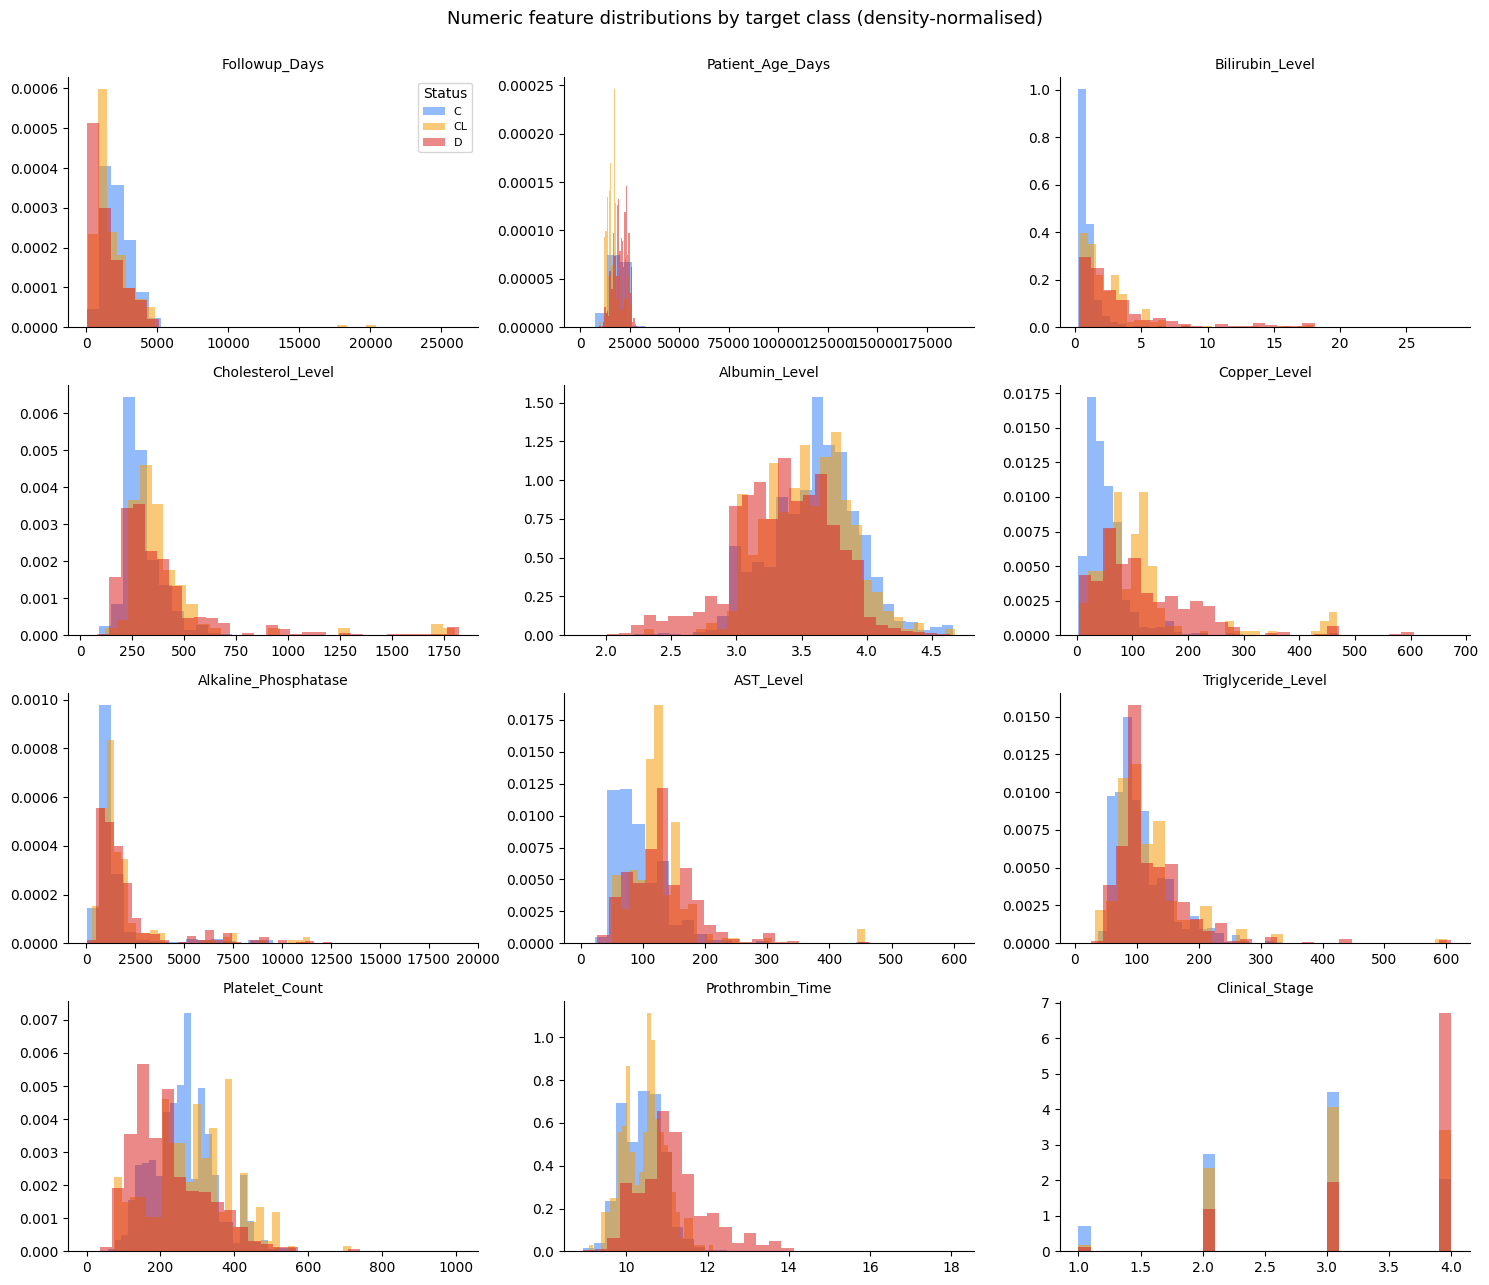

OBSERVATION
--------------------------------------------------------------
Features whose curves are clearly displaced between classes carry signal on
their own. Features whose curves overlap heavily may still contribute in
combination with others — tree models can exploit such interactions, whereas
Logistic Regression generally cannot without explicit feature engineering.

Heavily right-skewed features with long tails also suggest that a linear model
will struggle unless the values are transformed or robustly scaled.


In [10]:
# 4.5  Numeric feature distributions by class 
# Select all numeric columns for analysis, excluding the ID column which has no predictive value 
num_cols_eda = [c for c in train.select_dtypes(include="number").columns
                if c != ID_COL]

# Set up a grid layout for the plots: 3 columns wide, and enough rows to fit all numeric features 
n_cols = 3
n_rows = int(np.ceil(len(num_cols_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.2 * n_rows)) 
# Flatten the 2D array of axes into a 1D list so we can easily loop over it 
axes = np.atleast_1d(axes).flatten()

class_colors = {"C": "#3b82f6", "CL": "#f59e0b", "D": "#dc2626"}

# Loop through each numeric feature to create a subplot 
for i, col in enumerate(num_cols_eda):
    ax = axes[i] 
    # For each target class (C, CL, D), plot a separate distribution histogram 
    for cls in CLASSES: 
        # Extract non-missing values for the current class and current column 
        vals = train.loc[train[TARGET] == cls, col].dropna()
        if len(vals): 
            # Plot the histogram. density=True normalizes the heights so classes with different sizes are comparable 
            ax.hist(vals, bins=30, alpha=0.55, label=cls,
                    color=class_colors[cls], edgecolor="none", density=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False) 
    # Add a legend only to the very first subplot to avoid clutter 
    if i == 0:
        ax.legend(title="Status", fontsize=8)

# Hide any extra empty subplots if the number of features isn't a perfect multiple of 3 
for j in range(len(num_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric feature distributions by target class (density-normalised)",
             fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

print("OBSERVATION")
print("-" * 62)
print("Features whose curves are clearly displaced between classes carry signal on")
print("their own. Features whose curves overlap heavily may still contribute in")
print("combination with others — tree models can exploit such interactions, whereas")
print("Logistic Regression generally cannot without explicit feature engineering.")
print()
print("Heavily right-skewed features with long tails also suggest that a linear model")
print("will struggle unless the values are transformed or robustly scaled.")

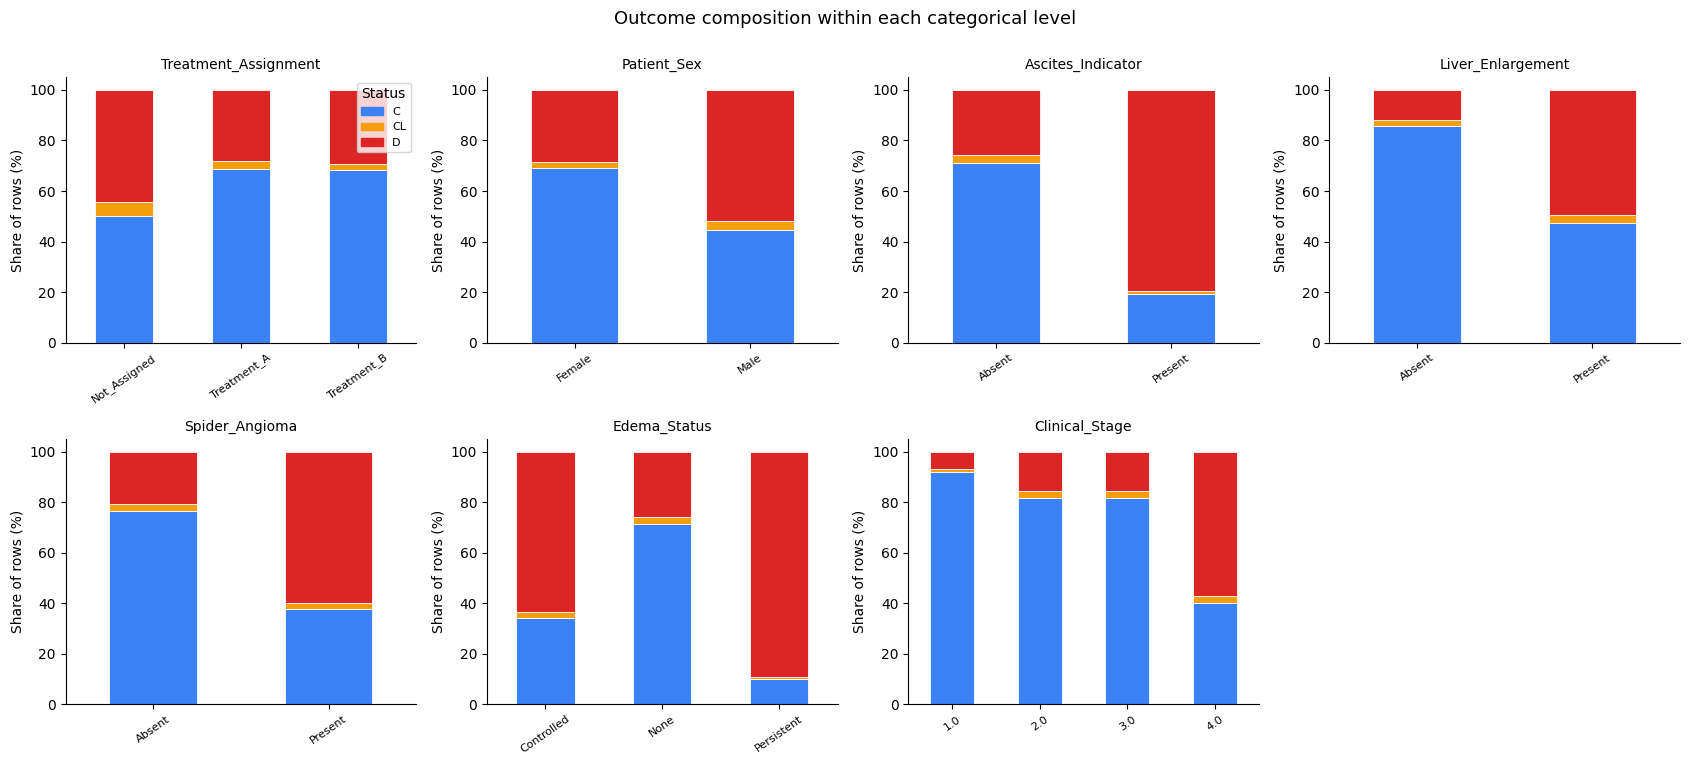

OBSERVATION
--------------------------------------------------------------
Where the coloured bands shift noticeably between levels, the feature
discriminates between outcomes and is worth keeping. Where every level shows
the same composition, the feature adds little on its own.

Some of these variables are NOMINAL — the levels have no natural ordering.
Label-encoding them would impose an artificial order (implying, for example,
that one treatment arm is 'greater than' another), which a linear model would
take literally.

DECISION -> one-hot encode for Logistic Regression; let the boosting libraries
            handle categorical columns through their native mechanisms.


In [11]:
# 4.6  Categorical features versus the target 
# Set up a grid layout: 4 columns wide 
n_cols = 4
n_rows = int(np.ceil(len(CAT_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 3.8 * n_rows))
axes = np.atleast_1d(axes).flatten()

# Loop through each categorical feature 
for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    # Create a crosstab calculating the percentage of each target class within each categorical level 
    ct = pd.crosstab(train[col], train[TARGET], normalize="index") 
    # Ensure the columns follow the exact ['C', 'CL', 'D'] order, filling missing ones with 0 
    ct = ct.reindex(columns=CLASSES, fill_value=0) * 100 
    
    # Plot a 100% stacked bar chart 
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[class_colors[c] for c in CLASSES],
            edgecolor="white", linewidth=0.6, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Share of rows (%)")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Create a custom global legend for all subplots based on the custom colors 
handles = [plt.Rectangle((0, 0), 1, 1, color=class_colors[c]) for c in CLASSES]
axes[0].legend(handles, CLASSES, title="Status", fontsize=8)

# Hide any unused subplots 
for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outcome composition within each categorical level", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

print("OBSERVATION")
print("-" * 62)
print("Where the coloured bands shift noticeably between levels, the feature")
print("discriminates between outcomes and is worth keeping. Where every level shows")
print("the same composition, the feature adds little on its own.")
print()
print("Some of these variables are NOMINAL — the levels have no natural ordering.")
print("Label-encoding them would impose an artificial order (implying, for example,")
print("that one treatment arm is 'greater than' another), which a linear model would")
print("take literally.")
print()
print("DECISION -> one-hot encode for Logistic Regression; let the boosting libraries")
print("            handle categorical columns through their native mechanisms.")

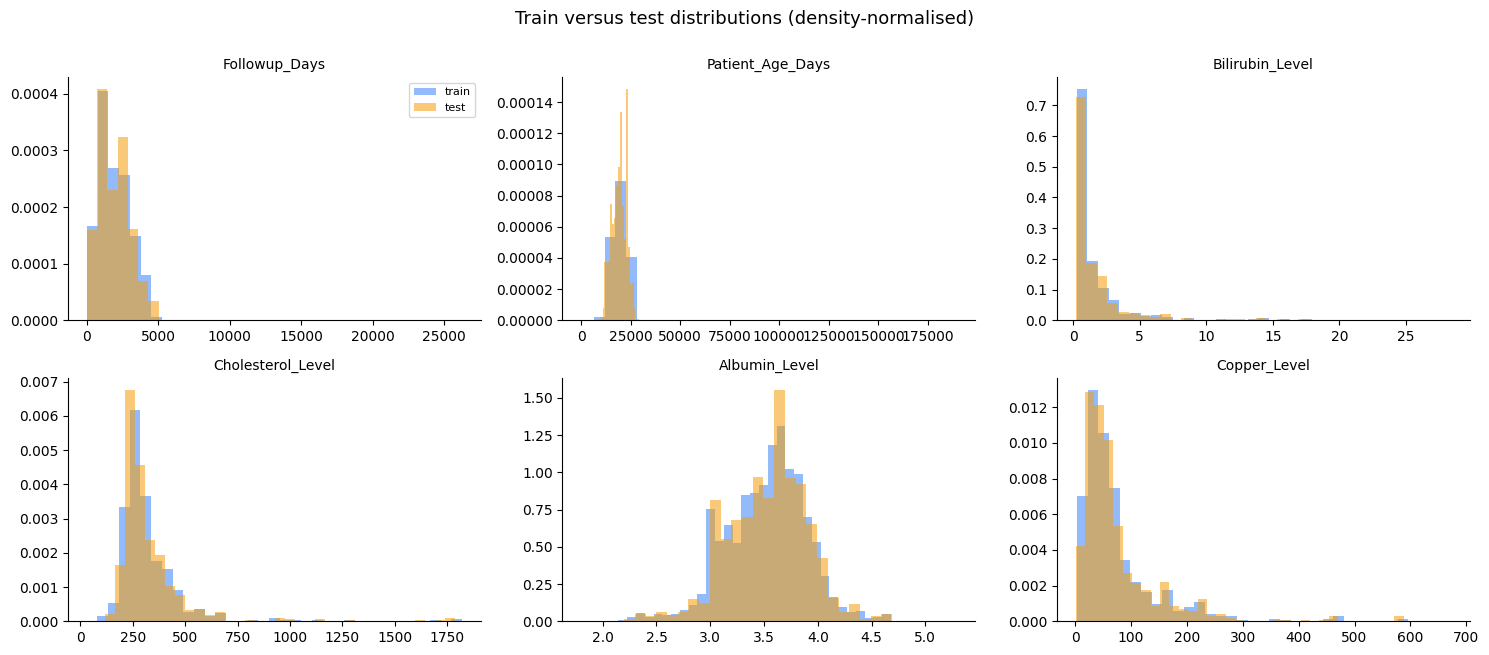

SUMMARY STATISTICS: TRAIN VERSUS TEST
          Feature  train_mean  test_mean  train_std  test_std  train_na%  test_na%
    Followup_Days    1978.274   1964.716   1380.381  1243.237        0.0       0.0
 Patient_Age_Days   19311.575  19305.011   3942.175  3657.610        0.0       0.0
  Bilirubin_Level       1.810      1.853      2.605     2.733        0.0       0.0
Cholesterol_Level     329.262    330.536    183.345   189.082       55.5      56.2
    Albumin_Level       3.524      3.527      0.373     0.375        0.0       0.0
     Copper_Level      74.769     74.914     73.227    76.435       43.8      44.5

OBSERVATION
--------------------------------------------------------------
Validation data is drawn from train, whereas the leaderboard is scored on test.
Where the two distributions differ, the cross-validation score will not track
the leaderboard score exactly.

DECISION -> treat cross-validation as the primary decision criterion and read
            the public leaderboard as

In [12]:
# 4.7  Train versus test distributions 
# Select up to the first 6 numeric features that exist in both train and test sets to compare 
compare_cols = [c for c in num_cols_eda if c in test.columns][:6]

# Create a 2x3 grid for the comparison histograms 
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    ax = axes[i] 
    # Plot the normalized distribution (density=True) for the train set in blue 
    ax.hist(train[col].dropna(), bins=35, alpha=0.55, density=True,
            label="train", color="#3b82f6", edgecolor="none") 
    # Plot the normalized distribution for the test set over it in orange 
    ax.hist(test[col].dropna(),  bins=35, alpha=0.55, density=True,
            label="test",  color="#f59e0b", edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False) 
    # Add a legend to the first plot 
    if i == 0:
        ax.legend(fontsize=8)

# Hide any unused subplots 
for j in range(len(compare_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train versus test distributions (density-normalised)", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

# Numeric summary of the shift
print("SUMMARY STATISTICS: TRAIN VERSUS TEST")
print("=" * 62)
rows = [] 
# Calculate mean, standard deviation, and missingness percentage for both sets to detect data drift 
for col in compare_cols:
    rows.append({
        "Feature":     col,
        "train_mean":  round(train[col].mean(), 3),
        "test_mean":   round(test[col].mean(),  3),
        "train_std":   round(train[col].std(),  3),
        "test_std":    round(test[col].std(),   3),
        "train_na%":   round(train[col].isnull().mean() * 100, 1),
        "test_na%":    round(test[col].isnull().mean()  * 100, 1),
    })
print(pd.DataFrame(rows).to_string(index=False))

print()
print("OBSERVATION")
print("-" * 62)
print("Validation data is drawn from train, whereas the leaderboard is scored on test.")
print("Where the two distributions differ, the cross-validation score will not track")
print("the leaderboard score exactly.")
print()
print("DECISION -> treat cross-validation as the primary decision criterion and read")
print("            the public leaderboard as a secondary, noisier signal. The public")
print("            leaderboard is computed on only a fraction of the test set.")

## Step 5 — Feature Matrix Construction

**Role & Purpose:**
In this step, I build a universal, **model-agnostic** feature set that all subsequent models will share. 

The most important rule here is that **no data fitting happens at this stage**. If I were to let an imputer learn a median or a scaler learn a mean right now on the entire dataset, information from the validation folds would "leak" into the training process, giving me a falsely optimistic Cross-Validation score. Therefore, all learning-based transformations will strictly happen later, safely isolated inside each CV fold.

**Workflow:**
For now, I only apply two safe, structural transformations:
1. **The `in_trial` indicator:** Based on the joint missingness discovered in my EDA, this flag explicitly marks patients who participated in the clinical trial.
2. **The `__MISSING__` category:** Since EDA showed that missing values in categorical columns are clinically informative, I treat "missing" as its own distinct category rather than just noise to be deleted.


In [13]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build the shared, model-agnostic feature frame.

    No fitting takes place in this function, so it can be applied to train and test
    independently without any risk of leakage.

    Parameters
    ----------
    df : pd.DataFrame
        Raw competition dataframe (train or test).

    Returns
    -------
    pd.DataFrame
        Feature frame with the target and ID removed, the `in_trial` indicator
        added, and categorical NaNs replaced by an explicit sentinel level.
    """
    # Create a copy of the dataframe and drop the target and ID columns if they exist.
    # We only want predictive features in this matrix, not identifiers or the answer. 
    X = df.drop(columns=[c for c in (TARGET, ID_COL) if c in df.columns]).copy()

# 1. Structural missingness indicator (motivated by EDA 4.4):
    # Sum the missing values across the trial-specific columns. 
    # If the sum is 0 (no missing values), it means the patient was in the trial (True -> 1). 
    X["in_trial"] = (X[TRIAL_BLOCK].isna().sum(axis=1) == 0).astype(int)

# 2. Explicit __MISSING__ category
    # For a categorical column, a missing value is a meaningful state
    # ("measurement not taken"), so it becomes its own level rather than a NaN.
    # .astype("object") first keeps this compatible across pandas versions.
    # Loop through all categorical columns defined earlier. 
    for col in CAT_COLS: 
        # Convert the column to 'object' type first for safe pandas manipulation,
        # fill any NaNs with the explicit string "__MISSING__", 
        # and then ensure the whole column is treated as strings. 
        X[col] = X[col].astype("object").fillna("__MISSING__").astype(str)

    return X


# Apply the safe transformation function to both training and testing datasets 
X      = build_features(train)
X_test = build_features(test)

# Encode the target variable into a numerical format for the machine learning models.
# Encode the target: C -> 0, CL -> 1, D -> 2Finally, convert it to a NumPy array.
y = train[TARGET].map({c: i for i, c in enumerate(CLASSES)}).to_numpy()

# Define numeric columns by taking all columns in X and excluding the categorical ones 
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

# Safety Checks (Assertions) 
# Strictly verify that the training and testing datasets have the exact same columns.
# If they don't, the code will throw an error here to prevent training failures later.
assert list(X.columns) == list(X_test.columns), "Train and test columns are misaligned." 

# Verify that our target encoding process didn't produce any unexpected NaNs 
assert not np.isnan(y).any(), "Target encoding produced NaN values."

# Final Matrix Summary 
# Print the shapes of the newly created feature matrices to confirm dimensions
print(f"Feature matrix (train) : {X.shape}")
print(f"Feature matrix (test)  : {X_test.shape}") 
# Print the shape of the target array and the exact count of each class (0, 1, 2) 
print(f"Target vector          : {y.shape}   "
      f"[C={(y==0).sum()}, CL={(y==1).sum()}, D={(y==2).sum()}]")
print() 

# Print the total count and the actual names of the numeric and categorical features 
print(f"Numeric features     ({len(NUM_COLS):2d}): {NUM_COLS}")
print(f"Categorical features ({len(CAT_COLS):2d}): {CAT_COLS}")
print() 

# Verify the distribution of our newly engineered 'in_trial' feature 
print("in_trial breakdown:")
print(X["in_trial"].value_counts().rename({0: "not in trial", 1: "in trial"}).to_string())

Feature matrix (train) : (12000, 19)
Feature matrix (test)  : (10000, 19)
Target vector          : (12000,)   [C=8151, CL=317, D=3532]

Numeric features     (12): ['Followup_Days', 'Patient_Age_Days', 'Bilirubin_Level', 'Cholesterol_Level', 'Albumin_Level', 'Copper_Level', 'Alkaline_Phosphatase', 'AST_Level', 'Triglyceride_Level', 'Platelet_Count', 'Prothrombin_Time', 'in_trial']
Categorical features ( 7): ['Treatment_Assignment', 'Patient_Sex', 'Ascites_Indicator', 'Liver_Enlargement', 'Spider_Angioma', 'Edema_Status', 'Clinical_Stage']

in_trial breakdown:
in_trial
in trial        6737
not in trial    5263


## Step 6 — Validation Strategy

**Role & Purpose and workflow:**
### Why stratified folds
Because our target class distribution is heavily imbalanced, the rarest class covers only a few percent of the data. A standard random data split could easily result in validation folds containing very few—or even zero—samples of the minority class. This would cause wild, unstable fluctuations in our Log Loss evaluation. The fold-to-fold variance in
Log Loss would be driven by that accident rather than by model quality. `StratifiedKFold` preserves the class proportions in every fold.

### Why the folds are built onceand shared
All of our models will be evaluated on the exact same splits. This design choice is critical for two reasons:
*   **Fair Comparison:** Any difference in cross-validation performance reflects the actual strength of the model, not the luck of how the data was split.
*   **Safe Blending:** Because every model makes predictions on the exact same held-out rows, their Out-of-Fold predictions line up row-by-row, allowing us to safely combine them later.

### What "out-of-fold" predictions mean
For each row in the training set, its prediction comes from the one fold where that
row was held out — a model that never saw it during training. Concatenating these
gives a full-length prediction vector that is honest for every row, which is what
makes OOF predictions the right basis both for comparison and for weight optimisation. 

### What is Cross-Validation?
Split the training data into n_folds pieces. Train on all pieces (folds)) except one fold (that fold is used for validation), 
then check the predictions on the left out (the validation fold).) Repeat so every piece gets a turn being left out. 
This estimates how well the model performs on data it hasn't been before.

In [14]:
def make_folds(y_arr: np.ndarray, n_splits: int = N_FOLDS, seed: int = SEED) -> list:
    """Create the stratified folds once; every model reuses this exact list.

    Returns
    -------
    list of (train_index, valid_index) tuples
    """
    
    # Initialize StratifiedKFold to shuffle data and maintain class proportions across splits
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed) 
    # Generate and return the list of (train_index, valid_index) tuples 
    return list(skf.split(np.zeros(len(y_arr)), y_arr))


# Generate the shared folds using our target array 
FOLDS = make_folds(y)

print(f"Created {N_FOLDS} stratified folds (seed={SEED})")
print()
print(f"{'Fold':>5} | {'n_train':>8} | {'n_valid':>8} | {'%C':>6} | {'%CL':>6} | {'%D':>6}")
print("-" * 58) 

# Loop through each fold to inspect its size and class distribution proportions 
for i, (tr_idx, va_idx) in enumerate(FOLDS, start=1):  
    # Calculate the percentage of each class in the current validation fold 
    pct = np.bincount(y[va_idx], minlength=3) / len(va_idx) * 100
    print(f"{i:>5} | {len(tr_idx):>8,} | {len(va_idx):>8,} | "
          f"{pct[0]:>5.1f}% | {pct[1]:>5.1f}% | {pct[2]:>5.1f}%")

# Calculate the overall class proportions for the entire dataset as a baseline reference 
overall = np.bincount(y, minlength=3) / len(y) * 100
print("-" * 58)
print(f"{'FULL':>5} | {len(y):>8,} | {'':>8} | "
      f"{overall[0]:>5.1f}% | {overall[1]:>5.1f}% | {overall[2]:>5.1f}%")
print()
print("Every fold reproduces the overall class proportions, as intended.")

Created 5 stratified folds (seed=42)

 Fold |  n_train |  n_valid |     %C |    %CL |     %D
----------------------------------------------------------
    1 |    9,600 |    2,400 |  68.0% |   2.6% |  29.4%
    2 |    9,600 |    2,400 |  67.9% |   2.6% |  29.5%
    3 |    9,600 |    2,400 |  67.9% |   2.6% |  29.5%
    4 |    9,600 |    2,400 |  67.9% |   2.7% |  29.4%
    5 |    9,600 |    2,400 |  67.9% |   2.7% |  29.4%
----------------------------------------------------------
 FULL |   12,000 |          |  67.9% |   2.6% |  29.4%

Every fold reproduces the overall class proportions, as intended.


### Cross-validation driver

`run_cv` is the single function that trains every model. Each model supplies a
`train_fn` that receives one fold's data and returns two probability arrays.
Everything else — looping over folds, collecting OOF predictions, averaging the
test predictions, scoring, and recording results — happens here.

Keeping this logic in one place is what guarantees that all four models are
evaluated under identical conditions.

**Test predictions are averaged across folds.** Each fold trains on 80% of the data
and produces its own view of the test set; averaging the five gives a more stable
prediction than any single fold could, and it costs nothing extra since the models
are being trained anyway.

In [15]:
def run_cv(model_name, train_fn, verbose=True):
    # Runs the same 5-fold cross-validation for any model.
    # model_name: name used to store this model's results in RESULTS.
    # train_fn: a function that trains on 4 folds and predicts on the
    #           5th fold + the real test set. Must return (proba_va, proba_te).
    # Returns: oof (out-of-fold predictions), test_pred (averaged test
    #          predictions), cv_score (overall Log Loss).
    # Initialize zero arrays to store full-length OOF predictions and averaged test predictions 
    oof       = np.zeros((len(X), 3))
    test_pred = np.zeros((len(X_test), 3))
    fold_scores = []
    t_start = time.time()

    if verbose:
        print(f"{model_name}")
        print("-" * 46)
    
    # Iterate through each pre-defined fold split 
    for fold_idx, (tr_idx, va_idx) in enumerate(FOLDS): 
        # Split data into training and validation subsets for the current fold 
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx],      y[va_idx]

        # The model handles its own preprocessing inside this call, fitting only
        # on X_tr, so no validation-fold information reaches the fitted objects.
        # Call the model-specific training function. 
        # Preprocessing and fitting happen strictly inside here using X_tr only.
        proba_va, proba_te = train_fn(X_tr, y_tr, X_va, X_test, y_va, fold_idx) 

        # Store validation probabilities into their exact original row indices (each row predicted once) 
        oof[va_idx] = proba_va          
        # each row is predicted exactly once 
        # Accumulate test probabilities divided by the number of folds to average them later 
        test_pred  += proba_te / N_FOLDS  # fold-averaged test prediction
        

        # Calculate Log Loss score for the current fold 
        fold_score = log_loss(y_va, proba_va, labels=[0, 1, 2])
        fold_scores.append(fold_score)
        if verbose:
            print(f"  fold {fold_idx + 1}   log loss = {fold_score:.5f}")
    
    # Calculate overall OOF Log Loss across the entire training dataset 
    cv_score = log_loss(y, oof, labels=[0, 1, 2])
    elapsed  = time.time() - t_start

    if verbose:
        print("-" * 46)
        print(f"  OOF log loss = {cv_score:.5f}   "
              f"(fold sd {np.std(fold_scores):.5f}, {elapsed:.0f}s)")
        print()
    
    # Save all evaluation metrics, predictions, and runtime into the global RESULTS dictionary: 
    RESULTS[model_name] = {
        "cv_score":    cv_score,
        "fold_scores": fold_scores,
        "fold_std":    float(np.std(fold_scores)),
        "oof":         oof,
        "test_pred":   test_pred,
        "runtime_s":   round(elapsed, 1),
    }
    return oof, test_pred, cv_score


print("Cross-validation driver ready.")

Cross-validation driver ready.


## Step 7 — Model 1: Logistic Regression (Baseline)

**Role & purpose and workflow:** 
This model serves as our foundational **baseline**. In machine learning, a baseline is not meant to be a weak solution; 
rather, it establishes a reliable performance reference point. Every advanced model I build later will be judged by how much it improves upon this score. 
If a complex model cannot beat this simple baseline, it means our extra complexity is unjustified.

**Why preprocessing is critical here:** 
Unlike tree-based models, Logistic Regression is a linear mathematical model that demands rigorous data preparation to converge properly:

| Requirement | Reason & Expected Goal|
| :--- | :--- |
| Median imputation | The model cannot accept `NaN`. Filling with median prevents training failure. |
| Missing indicators | Preserves the clinical signal discovered during our EDA, ensuring the model remembers which values were originally absent. |
| Standard scaling | The optimiser converges poorly when features live on wildly different scales. Puts all numeric features on the same numerical scale, preventing features with large values from dominating the optimization process. |
| One-hot encoding | The variables are nominal; integer codes would imply a false ordering. Converts nominal text categories into binary columns, preventing the model from assuming false numerical ordering. |

**Key hyperparameter.** 
*   `C=0.5`: Controls the inverse L2 regularization strength. A moderate shrinkage helps prevent overfitting, 
             especially since one-hot encoding expands the feature matrix significantly.
             In scikit-learn's LogisticRegression, 'C' is the inverse of regularization strength (C = 1 / lambda).
             A smaller C value specifies stronger L2 regularization (shrinkage), which penalizes large coefficients to prevent overfitting. 
             We set C=0.5 as a balanced default because our one-hot encoded categorical variables significantly expand the feature matrix, 
             making strong regularization necessary to keep the decision boundary stable and generalizable.

In [16]:
def train_logreg(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    """Logistic Regression with a fully self-contained preprocessing pipeline.

    Every transformer is fitted inside this function on X_tr only, so calling it
    once per fold keeps the cross-validation honest.
    """ 

    # Define a ColumnTransformer to handle numerical and categorical branches separately
    preprocessor = ColumnTransformer([ 

        # 1. Numeric branch pipeline 
        # Impute missing values with the median, add missing indicator columns to retain signal, then standardize scales
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale",  StandardScaler()),
        ]), NUM_COLS),

        # 2. Categorical branch pipeline 
        # One-hot encode string categories. 'handle_unknown="ignore"' ensures safety against unseen categories in test data.
        # 'min_frequency=5' groups very rare categories together, keeping the feature matrix compact and stable.
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            min_frequency=5,
        ), CAT_COLS),
    ])
    
    # Initialize the Logistic Regression model with tuned parameters
    model = LogisticRegression(
        C=0.5,             # Inverse L2 regularization strength to prevent overfitting
        max_iter=3000,     # Generous iteration budget to ensure the numerical solver reaches full convergence 
        random_state=SEED, # Fixed seed for complete reproducibility
    )
    
    # Combine preprocessing steps and the model into a single sequential scikit-learn Pipeline 
    pipe = Pipeline([("prep", preprocessor), ("model", model)]) 
    
    # Fit the entire pipeline using ONLY the training fold data (X_tr, y_tr) 
    pipe.fit(X_tr, y_tr)
    
    # Return predicted probabilities for both the validation fold (X_va) and the test set (X_te) 
    return pipe.predict_proba(X_va), pipe.predict_proba(X_te)

# Execute cross-validation for Logistic Regression using our shared runner function 
oof_lr, test_lr, score_lr = run_cv("Logistic Regression", train_logreg)

Logistic Regression
----------------------------------------------
  fold 1   log loss = 0.46607
  fold 2   log loss = 0.45791
  fold 3   log loss = 0.46225
  fold 4   log loss = 0.43779
  fold 5   log loss = 0.45580
----------------------------------------------
  OOF log loss = 0.45596   (fold sd 0.00975, 0s)



## Step 8 — Model 2: XGBoost

**Role & Purpose:** 
Logistic Regression can only draw linear decision boundaries in the
feature space it is given. Gradient-boosted trees build non-linear boundaries and
capture feature interactions automatically, which is usually decisive on tabular
clinical data where risk factors combine rather than add.
While Logistic Regression is limited to drawing linear decision boundaries, 
real-world clinical data often involves complex interactions 
where risk factors combine rather than simply add up. 
The purpose of this step is to implement **XGBoost (Extreme Gradient Boosting)**—a powerful tree-based ensemble model 
designed to capture non-linear patterns and automatic feature interactions.

**Workflow & Key Advantages Over Baseline:** 
1. **No Scaling Required:** Decision trees split data based on numerical thresholds, 
meaning monotonic feature scaling (like StandardScaler) has zero effect.
2. **Native Missing Value Handling:** XGBoost does not require explicit median imputation or missing value filling. 
During training, it automatically learns a default routing direction for missing values at every split node.
3. **Native Categorical Support:** By setting `enable_categorical=True`, 
we can feed string/categorical columns directly into the model without messy One-Hot Encoding.

**Expected Objective & Outcome:**
The goal is to achieve a significantly lower Out-of-Fold (OOF) Log Loss than our Logistic Regression baseline 
by leveraging gradient-boosted decision trees with early stopping to prevent overfitting.

### Hyperparameters

| Parameter | Value | Purpose |
|---|---|---|
| `learning_rate` | 0.03 | Small steps; more trees, better generalisation |
| `n_estimators` | 3000 | An upper bound — early stopping decides the real count |
| `max_depth` | 5 | Caps interaction order; deeper trees overfit quickly here |
| `min_child_weight` | 8 | Minimum weight in a leaf; blocks splits on tiny groups |
| `subsample` | 0.85 | Row sampling per tree, for variance reduction |
| `colsample_bytree` | 0.7 | Column sampling per tree, decorrelates the ensemble |
| `reg_lambda` | 2.0 | L2 penalty on leaf weights |
| `early_stopping_rounds` | 150 | Stops once the validation fold stops improving |

**Notes:**
*   `reg_lambda = 2.0`: Set L2 regularization via reg_lambda=2.0. 
                        L2 regularization (Ridge-like penalty) adds a proportional penalty based on the squared magnitude of the leaf weights (scores) to the model's loss function. 
                        Setting reg_lambda to 2.0 discourages overly complex trees, prevents the model from relying too heavily on any single leaf or noisy split, 
                        and forces smoother probability estimates—ultimately improving out-of-fold generalization and reducing Log Loss. 
                        $$\text{L2 Penalty} = \lambda \sum w_i^2$$

In [17]:
def train_xgb(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    """XGBoost with native categorical support and early stopping."""

    def to_categorical(df):
        """XGBoost requires converting catergorical columns to the pandas 'category' dtype."""
        df = df.copy()
        for col in CAT_COLS:
            df[col] = df[col].astype("category")
        return df
    
    # Transform train, validation, and test sets so their categorical columns have the proper pandas dtype 
    Xtr, Xva, Xte = map(to_categorical, (X_tr, X_va, X_te))
    
    # Initialize the XGBoost classifier with custom hyperparameters optimized for tabular clinical data 
    model = xgb.XGBClassifier(
        objective="multi:softprob",   # Output predicted probabilities for each of the 3 classes instead of hard labels 
        num_class=3,                  # Specify the total number of target classes (C, CL, D) 
        n_estimators=3000,            # High upper bound for trees; early stopping will determine the optimal count 
        learning_rate=0.03,           # Small learning rate for gradual, stable boosting steps and better generalization 
        max_depth=5,                  # Limit tree depth to prevent overfitting on complex feature interactions 
        min_child_weight=8,           # Minimum sum of instance weight needed in a child; blocks splits on tiny groups 
        subsample=0.85,               # Sample 85% of rows per tree to introduce randomness and reduce variance
        colsample_bytree=0.7,         # Sample 70% of columns per tree to decorrelate ensemble trees 
        reg_lambda=2.0,               # L2 regularization penalty on leaf weights to control model complexity 
        tree_method="hist",           # Use histogram-based splitting algorithm for fast execution and low memory usage 
        enable_categorical=True,      # Instruct XGBoost to consume pandas 'category' dtype directly without manual encoding 
        early_stopping_rounds=150,    # Stop training if validation metric does not improve for 150 consecutive rounds 
        eval_metric="mlogloss",       # Directly optimize the competition metric (Multi-class Log Loss) 
        random_state=SEED,            # Fixed seed for reproducibility across runs 
        verbosity=0,                  # Suppress unnecessary warning logs during training 
    )

    # Train the model using the training fold, while monitoring performance on the validation fold (eval_set) 
    # to trigger early stopping. The validation fold is strictly used for stopping criteria, never for weight optimization.
    model.fit(Xtr, y_tr, eval_set=[(Xva, y_va)], verbose=False)
    
    # Return predicted probabilities for the validation fold and test set respectively 
    return model.predict_proba(Xva), model.predict_proba(Xte)

# Execute cross-validation for XGBoost using our shared evaluation driver 
oof_xgb, test_xgb, score_xgb = run_cv("XGBoost", train_xgb)

XGBoost
----------------------------------------------
  fold 1   log loss = 0.37690
  fold 2   log loss = 0.37036
  fold 3   log loss = 0.37593
  fold 4   log loss = 0.36208
  fold 5   log loss = 0.38531
----------------------------------------------
  OOF log loss = 0.37412   (fold sd 0.00768, 21s)



## Step 9 — Model 3: LightGBM

**Role & Purpose:** 
The two libraries solve the same problem but grow
trees differently. XGBoost grows trees **level-wise** — it expands every node at a given
depth before going deeper. LightGBM grows **leaf-wise** — it repeatedly splits
whichever leaf promises the largest loss reduction, producing deeper, asymmetric
trees for the same number of nodes.

That difference matters here for a practical reason: two models that make *different
kinds* of mistakes blend better than two models that are individually stronger but
correlated. LightGBM is included as much for diversity as for its standalone score. 

**Workflow & Diversity Value:**
* **Asymmetric Growth:** Leaf-wise growth produces deeper, 
more asymmetric trees that can capture complex patterns faster and with fewer total splits.
* **Model Diversity for Blending:** Because LightGBM makes *different kinds of errors* compared to XGBoost, 
including it in our workflow introduces valuable model diversity. 
Two strong models with non-identical error patterns will blend much better than two correlated models.
* **Complexity Control:** Instead of `max_depth`, LightGBM controls tree size strictly via `num_leaves` 
(set conservatively to 24) combined with `min_child_samples=40` to prevent overfitting on noisy data splits.

**Expected Objective & Outcome:**
Train a fast, memory-efficient gradient boosting model utilizing native categorical handling and early stopping, 
yielding an independent set of Out-of-Fold probabilities optimized for subsequent model ensembling.

**Note on tree size.** LightGBM controls complexity through `num_leaves` rather than
`max_depth`. With leaf-wise growth, `num_leaves` is the parameter that actually
constrains the model; a value of 24 is conservative and appropriate for a dataset of
this size.

**Notes:**
*   `reg_lambda = 2.0`: Set L2 regularization via reg_lambda=2.0. 
                        L2 regularization (Ridge-like penalty) adds a proportional penalty based on the squared magnitude of the leaf weights (scores) to the model's loss function. 
                        Setting reg_lambda to 2.0 discourages overly complex trees, prevents the model from relying too heavily on any single leaf or noisy split, 
                        and forces smoother probability estimates—ultimately improving out-of-fold generalization and reducing Log Loss.
                        $$\text{L2 Penalty} = \lambda \sum w_i^2$$

In [18]:
def train_lgbm(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    """LightGBM with native categorical handling and early stopping."""

    def to_categorical(df):
        """LightGBM detects and specially convert columns to pandas 'category' dtype."""
        df = df.copy()
        for col in CAT_COLS:
            df[col] = df[col].astype("category")
        return df
    
    # Transform train, validation, and test sets to ensure categorical columns use the 'category' data type 
    Xtr, Xva, Xte = map(to_categorical, (X_tr, X_va, X_te))
    
    # Initialize the LightGBM classifier with robust parameters designed for tabular classification 
    model = lgb.LGBMClassifier(
        objective="multiclass",   # Set objective to multi-class classification to output class probabilities 
        num_class=3,              # Define the total number of unique target outcomes (C, CL, D) 
        n_estimators=3000,        # High upper limit for boosting rounds; controlled by early stopping 
        learning_rate=0.03,       # Small step size per iteration to ensure stable convergence and generalization 
        num_leaves=24,            # Primary complexity control under leaf-wise growth (must be less than 2^max_depth) 
        min_child_samples=40,     # Minimum number of data samples required in a leaf; guards against noisy splits 
        feature_fraction=0.75,    # Randomly sample 75% of features per tree to decorrelate estimators 
        bagging_fraction=0.85,    # Randomly sample 85% of rows (data points) per iteration to reduce variance
        bagging_freq=1,           # Frequency (every 1 iteration) at which bagging row sampling is performed 
        reg_lambda=2.0,           # L2 regularization term on weights to penalize overly complex models 
        random_state=SEED,        # Fixed seed value to ensure absolute reproducibility across runs 
        verbose=-1,               # Suppress warning and informational output logs during model training 
    )
    
    # Train the LightGBM model on the training fold and use the validation fold for early stopping evaluation 
    model.fit(
        Xtr, y_tr,
        eval_set=[(Xva, y_va)],                              # Validation set monitored to catch potential overfitting 
        eval_metric="multi_logloss",                         # Optimize directly against the competition evaluation metric (Multi-class Log Loss) 
        callbacks=[lgb.early_stopping(150, verbose=False)],  # Halt training if validation loss doesn't improve for 150 rounds 
    )
    
    # Return predicted class probabilities for the validation fold and test dataset respectively 
    return model.predict_proba(Xva), model.predict_proba(Xte)

# Execute cross-validation for LightGBM using our shared pipeline evaluation driver 
oof_lgbm, test_lgbm, score_lgbm = run_cv("LightGBM", train_lgbm)

LightGBM
----------------------------------------------
  fold 1   log loss = 0.37721
  fold 2   log loss = 0.37117
  fold 3   log loss = 0.37736
  fold 4   log loss = 0.36234
  fold 5   log loss = 0.38514
----------------------------------------------
  OOF log loss = 0.37464   (fold sd 0.00758, 38s)



## Step 10 — Model 4: CatBoost

**Role & Purpose: Why it often wins on this kind of data.** 
CatBoost was designed around categoricalfeatures. 
While traditional models require manual encoding (like One-Hot or Label Encoding) 
which often leads to information loss or target leakage, 
CatBoost computes **ordered target statistics**: each categorical level is replaced 
by a target average computed only from rows that came *earlier* in a random permutation. 
That ordering is what prevents the target leakage that plagues naive target encoding.

**The important consequence:** do not one-hot encode before handing data to CatBoost.
Doing so discards the mechanism that makes it strong. Pass the raw string columns and
declare them via `cat_features`.

**Workflow & Critical Usage Rules:**
1. **Raw String Format:** We do **not** use One-Hot Encoding before feeding data to CatBoost. 
Instead, categorical columns are kept as raw text strings and declared explicitly via `cat_features`.
2. **Internal Processing:** CatBoost replaces categorical levels with target averages computed exclusively 
from rows appearing *earlier* in a random permutation, completely preventing target leakage.
3. **Cardinality Optimization:** Since our categorical columns have low cardinality (few unique levels), 
setting `one_hot_max_size=16` instructs CatBoost to internally one-hot encode them, speeding up execution without sacrificing accuracy.

**Expected Objective & Outcome:**
Train a robust gradient-boosted model optimized specifically for categorical-heavy tabular data, 
generating a powerful, independent set of Out-of-Fold probabilities to complete our model ensemble portfolio.

**Notes:** 
*  Every categorical column here has at most a handful of levels. 
For such low cardinality, `one_hot_max_size=16` tells CatBoost to one-hot
them internally instead of running the full target-statistics machinery — materially
faster with no measurable loss in score. This threshold should be lowered if
high-cardinality features are ever introduced.

*   `l2_leaf_reg = 3.0`: Set L2 regularization via l2_leaf_reg = 3.0. 
                        L2 regularization (Ridge-like penalty) adds a proportional penalty based on the squared magnitude of the leaf weights (scores) to the model's loss function. 
                        Setting l2_leaf_reg to 3.0 discourages overly complex trees, prevents the model from relying too heavily on any single leaf or noisy split, 
                        and forces smoother probability estimates—ultimately improving out-of-fold generalization and reducing Log Loss.
                        $$\text{L2 Penalty} = \lambda \sum w_i^2$$

In [19]:
def train_catboost(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    """CatBoost classifier pipeline operating directly on raw categorical string columns."""

    def to_string(df):
        """CatBoost natively expects to convert categorical columns to string type, not category dtype."""
        df = df.copy()
        for col in CAT_COLS:
            df[col] = df[col].astype(str)
        return df

    # Transform train, validation, and test datasets to ensure categorical features are standard strings 
    Xtr, Xva, Xte = map(to_string, (X_tr, X_va, X_te))
    cat_features  = list(CAT_COLS)

    # Wrap the feature data and categorical feature declarations into CatBoost's native 'Pool' data structure 
    pool_tr = Pool(Xtr, y_tr, cat_features=cat_features)
    pool_va = Pool(Xva, y_va, cat_features=cat_features)
    pool_te = Pool(Xte,       cat_features=cat_features)
    
    # Initialize the CatBoost classifier with optimized hyperparameters for tabular classification 
    model = CatBoostClassifier(
        loss_function="MultiClass",   # Optimize multi-class log loss across our target classes (C, CL, D) 
        iterations=3000,              # Maximum number of boosting iterations (trees); controlled by early stopping 
        learning_rate=0.04,           # Step size shrinkage used in updates to encourage strong generalization 
        depth=6,                      # Depth of the decision trees; standard balanced value for tabular data 
        l2_leaf_reg=3.0,              # L2 regularization penalty applied to leaf weights to prevent overfitting
        od_type="Iter",               # Overfitting detector type based on iteration tracking 
        od_wait=120,                  # Early stopping patience: halt training if validation metric doesn't improve for 120 rounds 
        one_hot_max_size=16,          # low-cardinality columns -> internal one-hot. Automatically one-hot encode categorical features with 16 or fewer unique levels 
        bootstrap_type="Bernoulli",   # Subsampling method for selecting rows per tree 
        subsample=0.85,               # Fraction of observations sampled per tree to introduce beneficial randomness 
        random_seed=SEED,             # Fixed random seed to ensure strict reproducibility 
        verbose=0,                    # Suppress training progress print statements to keep output clean 
        allow_writing_files=False,    # Prevent CatBoost from creating local snapshot files in the working directory 
    )
    
    # Train the model on the training pool while monitoring the validation pool for early stopping 
    model.fit(
        pool_tr, 
        eval_set=pool_va,             # Monitor validation performance to prevent overfitting 
        use_best_model=True,          # Automatically restore the model weights from the iteration with the best validation score 
        )
    
    # Return predicted class probabilities for the validation fold and test dataset using the optimal model state 
    return model.predict_proba(pool_va), model.predict_proba(pool_te)

# Execute cross-validation for CatBoost using our shared pipeline evaluation driver 
oof_cat, test_cat, score_cat = run_cv("CatBoost", train_catboost)

CatBoost
----------------------------------------------
  fold 1   log loss = 0.38726
  fold 2   log loss = 0.37929
  fold 3   log loss = 0.38791
  fold 4   log loss = 0.37240
  fold 5   log loss = 0.39050
----------------------------------------------
  OOF log loss = 0.38347   (fold sd 0.00669, 8s)



## Step 11 — Model Comparison

**Role & Purpose:**
All four models (Logistic Regression, XGBoost, LightGBM, and CatBoost) were trained on 
identical cross-validation folds with identical target encoding, and I also aggregated 
their Out-of-Fold (OOF) predictions, so these numbers are directly comparable.

**Core Evaluation Principles:**
1. **Rely on OOF cross-validation score, Not the Public Leaderboard:** 
Model selection must be guided strictly by cross-validation OOF Log Loss. 
The public leaderboard evaluates models on only a fraction of the test set, 
making it vulnerable to noise and leaderboard overfitting.
2. **Account for Fold Variance:** We evaluate not just the mean OOF score, 
but also the **Fold Standard Deviation (SD)**. A performance gap between two models that 
is smaller than their fold-to-fold variance should be treated as a tie rather than definitive superiority.

**Expected Objective & Outcome:**
Generate a clear summary table and visualization comparing all models by their Log Loss, 
standard deviation, and runtime, establishing which individual model performs best before we proceed to model blending.

In [20]:
# Create an empty list to store summary metrics for each trained model 
summary_rows = [] 

# Loop through the global RESULTS dictionary containing evaluation metrics for every model 
for name, info in RESULTS.items():
    summary_rows.append({
        "Model":       name,
        "OOF LogLoss": round(info["cv_score"], 5),           # Rounded OOF multi-class Log Loss score 
        "Fold SD":     round(info["fold_std"], 5),           # Standard deviation across the 5 validation folds 
        "Runtime (s)": info["runtime_s"],                    # Total execution time in seconds 
    })

# Convert the summary list into a pandas DataFrame, sort models from best (lowest Log Loss) to worst, and reset index 
results_df = (pd.DataFrame(summary_rows)
              .sort_values("OOF LogLoss")
              .reset_index(drop=True)) 

# Insert a 'Rank' column at the very beginning of the table based on sorted performance 
results_df.insert(0, "Rank", results_df.index + 1)

print("MODEL COMPARISON — lower Log Loss is better")
print("=" * 68)
print(results_df.to_string(index=False))

# Extract the baseline Logistic Regression score to calculate relative performance improvements 
baseline_score = RESULTS["Logistic Regression"]["cv_score"]
print()
print("Improvement over the Logistic Regression baseline:")
for _, r in results_df.iterrows():
    if r["Model"] != "Logistic Regression": 
        # Calculate absolute Log Loss reduction and percentage improvement 
        delta = baseline_score - r["OOF LogLoss"]
        print(f"  {r['Model']:<22s} {delta:+.5f}  "
              f"({delta / baseline_score * 100:+.2f}%)")

MODEL COMPARISON — lower Log Loss is better
 Rank               Model  OOF LogLoss  Fold SD  Runtime (s)
    1             XGBoost      0.37412  0.00768         20.9
    2            LightGBM      0.37464  0.00758         38.4
    3            CatBoost      0.38347  0.00669          8.0
    4 Logistic Regression      0.45596  0.00975          0.4

Improvement over the Logistic Regression baseline:
  XGBoost                +0.08184  (+17.95%)
  LightGBM               +0.08132  (+17.84%)
  CatBoost               +0.07249  (+15.90%)


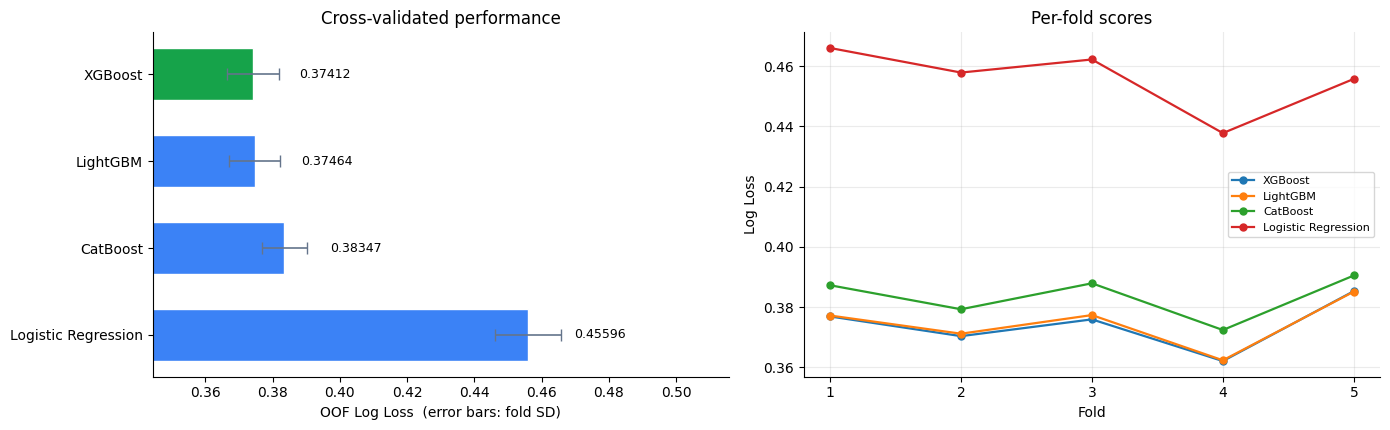

Best single model: XGBoost  (OOF Log Loss = 0.37412)


In [21]:
# Visual comparison, with fold variability shown as error bars 
# Create a figure with two side-by-side subplots for comprehensive visualization 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.4))

# Extract model names, OOF scores, and fold standard deviations in sorted performance order 
order  = results_df["Model"].tolist()
scores = results_df["OOF LogLoss"].tolist() 
# Safely extract fold standard deviations as a list for the error bars  
errs   = results_df["Fold SD"].tolist() 
# Define distinct colors: highlight the best-performing model differently from the rest 
cols   = ["#16a34a" if i == 0 else "#3b82f6" for i in range(len(order))]

# Create a horizontal bar chart displaying OOF Log Loss with fold standard deviation error bars 
bars = ax1.barh(order, scores, xerr=errs, color=cols,
                edgecolor="white", height=0.6,
                error_kw=dict(ecolor="#64748b", capsize=4, lw=1.2)) 

# Annotate each horizontal bar with its exact numerical Log Loss value 
for bar, val in zip(bars, scores):
    ax1.text(bar.get_width() + max(errs) + 0.004,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.5f}", va="center", fontsize=9)

ax1.set_xlabel("OOF Log Loss  (error bars: fold SD)")
ax1.set_title("Cross-validated performance", fontsize=12)
ax1.invert_yaxis()                                                              # Invert y-axis so the best-performing model appears at the top 
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_xlim(min(scores) - max(errs) - 0.02, max(scores) + max(errs) + 0.05)

# Per-fold detail: consistency matters as much as the mean 
# Plot line graphs on the second subplot to track individual fold scores for each model 
for name in order:
    ax2.plot(range(1, N_FOLDS + 1), RESULTS[name]["fold_scores"],
             marker="o", markersize=5, linewidth=1.6, label=name)
ax2.set_xlabel("Fold"); ax2.set_ylabel("Log Loss")
ax2.set_title("Per-fold scores", fontsize=12)
ax2.set_xticks(range(1, N_FOLDS + 1))
ax2.legend(fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.25)

plt.tight_layout(); plt.show()

# Identify and print the best single standalone model based on OOF cross-validation score 
best_single = results_df.iloc[0]["Model"]
print(f"Best single model: {best_single}  "
      f"(OOF Log Loss = {results_df.iloc[0]['OOF LogLoss']:.5f})")

## Step 12 — Optuna Hyperparameter Tuning (merged two-round search)
**Role & Purpose:**
Step 11 compared 4 models with hand-picked default settings. But those
defaults were guesses, not the actual best settings for this dataset — a
hyperparameter (e.g. how deep a tree can grow) is chosen before training
starts, and better choices usually mean better predictions. This step
uses Optuna, a library that tries many different hyperparameter
combinations automatically and remembers which one scored best, to search
for better settings than my original guesses for the 3 boosting models.

**Workflow:**

1. Scout Round (12.2–12.4, Round 1): Run a fast, cheap search (20 trials,
2 seeds) using my first guess at reasonable search ranges. The goal isn't
to find the final answer — it's to check whether those ranges are even
wide enough. If Optuna's best value lands exactly on a range's edge, that
is a sign it wants to go further but is being blocked by a boundary I set
too narrow.
2. Final Round (12.2–12.4, Round 2): After widening any range flagged by
the scout round, run a bigger, slower search (60 trials, 3 seeds) on the
corrected ranges to get the hyperparameter set actually used going
forward. Both rounds reuse the same train_fn/objective structure per
model, so the search logic is never duplicated between rounds.
3. Refit, Blend & Register (12.5–12.8): The trial-averaged scores above
are only used to rank hyperparameter candidates — they don't produce
reusable predictions. So each tuned model is retrained once on the same
seed=42 folds used everywhere else in this notebook, for a fair
apples-to-apples comparison against the Step 11 defaults. The 3 tuned
models are then blended with Nelder-Mead (same method as Step 14), and
the result is registered into RESULTS so later steps (Error Analysis,
Submission Generation) can find it automatically.

**Expected Objective & Outcome:**
A lower OOF Log Loss than the default-hyperparameter blend (Step 14,
0.37330), confirmed on the same folds so the improvement isn't just
random variation. Note: the scout round's boundary check only catches an
exact match to a range's edge, which works for integer parameters
(num_leaves, depth) but can miss a float parameter merely sitting close to
one — see 5.13/5.9 for where this limitation showed up in practice.

**Notes:**
  - SCOUT ROUND: run fast (few trials, few seeds) just to check whether the
    current search ranges are too tight (best param lands exactly on the
    min/max we declared -> sign that Optuna wants to go further but is
    being blocked by the boundary).
  - FINAL ROUND: after widening ranges if needed, run with more trials and
    more seeds to get the final parameter set used for comparison + blend.
  - Both rounds share one "engine" (suggest_params + make_objective), so we
    don't have to duplicate the objective function for every round like in
    the earlier draft.
 
1. **WHAT IS A "HYPERPARAMETER"?**
   A setting we choose BEFORE training starts — e.g. "how deep can a tree grow?" 
   or "how fast does the model learn?". This is different from the
   things the model learns automatically from the data. 
   Better settings usually mean better predictions.

2. **WHAT IS OPTUNA?**
   A library that tries many different combinations of hyperparameters
   for us automatically, and remembers which combination gave the best
   (lowest) Log Loss score. Each attempt is called a "trial".

3. **WHY TWO ROUNDS INSTEAD OF ONE?**
   - ROUND 1 (scout):  few trials, few seeds -> fast. Goal: get a rough
    idea of good values, and check if the min/max range we guessed is wide enough.
   - ROUND 2 (final):  more trials, more seeds -> slower but more reliable.
    We widen any range that Round 1 showed was too narrow, then search properly.

4. **Workflow idea**
   - Each model has its own objective function that defines the space for hyperparameters. 
   - The optimization process will run for specified number of trials, and the best hyperparameters 
   will be selected based on the average Log Loss accross multiple cross-validation folds.


In [22]:
# 12.1 Setup: install/import Optuna, round settings, shared scoring function
%pip install -q optuna                                                # install the optuna library
import optuna                                                         # import it to use it below
optuna.logging.set_verbosity(optuna.logging.WARNING)                  # stop optuna's own internal logging; will print our own results instead

# How many trials and seeds to use in each round.
# Round 1: few trials, few seeds -> fast, only meant to probe the ranges.
ROUND1_TRIALS, ROUND1_SEEDS = 20, [42, 123]                           # ROUND1_TRIALS = 20 is trying 20 different parameter combinations, ROUND1_SEEDS = [42, 123] is taking averages over 2 random data splits (fast)
# Round 2 (final round): more trials and seeds -> the parameter set actually used later.
ROUND2_TRIALS, ROUND2_SEEDS = 60, [42, 123, 2024]                     # ROUND1_TRIALS = 60 is trying 60 different parameter combinations, ROUND1_SEEDS = [42, 123, 2024] is taking averages over 3 random data splits (more reliable, slower)


def repeated_cv_score(train_fn, seeds, n_folds=N_FOLDS):
    """
    Measures how good a model is, using cross-validation repeated acreoss several random seeds.

    What is Cross-Validation?
       Split the training data into n_folds pieces. Train on all pieces (folds)) except one fold (that fold is used for validation), 
       then check the predictions on the left out (the validation fold).) Repeat so every piece gets a turn being left out. 
       This estimates how well the model performs on data it hasn't been before.

    Why repeat with different seeds?
       Splitting data into folds uses randomness, controlled by a "seed".
       One seed might give a lucky or unlucky split. Averaging over several seeds gives a score we can trust more.

    train_fn: function(X_tr, y_tr, X_va, y_va, seed) -> predicted probabilities
    seeds: list of seeds to repeat the whole process with
    """

    scores = []                                                         # will hold one Log Loss value per fold per seed
    for seed in seeds:                                                  # repeat the whole process once per seed
        folds = make_folds(y, n_splits=n_folds, seed=seed)              # split data into n_folds pieces using this seed
        for tr_idx, va_idx in folds:                                    # tr_idx = training rows, va_idx = validation rows
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]                 # select training / validation feature rows
            y_tr, y_va = y[tr_idx], y[va_idx]                           # select the matching training / validation labels
            proba_va = train_fn(X_tr, y_tr, X_va, y_va, seed)           # train the model, predict probabilities on validation rows
            scores.append(log_loss(y_va, proba_va, labels=[0, 1, 2]))   # compare predictions to real labels
    return float(np.mean(scores))                                       # return the average score over every fold and seed



Note: you may need to restart the kernel to use updated packages.


In [23]:
# 12.2 Data prep & train_fn for XGBoost
def to_categorical(df):  
    """
    XGBoost and LightGBM need categorical (text) columns to be marked
    with pandas' special "category" dtype, so the model treats them as
    categories instead of numbers.
    """
    df = df.copy()                                                                   # copy so we don't change the original dataframe by accident
    for col in CAT_COLS:                                                             # CAT_COLS = list of column names that are categorical
        df[col] = df[col].astype("category")                                         # convert that one column to "category" dtype
    return df


def xgb_train_fn(params):  
    """
    Takes a dictionary of hyperparameters and returns a ready-to-use
    training function with those hyperparameters already built in.
    This way, repeated_cv_score can call it the same way every time,
    no matter which hyperparameters we're testing.
    """
    def _fn(X_tr, y_tr, X_va, y_va, seed):
        Xtr, Xva = to_categorical(X_tr), to_categorical(X_va)                          # prepare categorical columns

        model = xgb.XGBClassifier(
            objective="multi:softprob",                                                # we have 3 classes, predict a probability for each one
            num_class=3,                                                               # tell XGBoost there are 3 classes                    
            n_estimators=3000,                                                         # max number of trees (early stopping usually stops sooner)
            early_stopping_rounds=150,                                                 # stop if the validation score hasn't improved in 150 rounds
            eval_metric="mlogloss",                                                    # metric used to judge validation performance while training
            tree_method="hist",                                                        # a faster training method, good for larger datasets
            enable_categorical=True,                                                   # allow XGBoost to use the "category" columns directly
            verbosity=0,                                                               # don't print XGBoost's own internal logs
            random_state=seed,                                                         # controls internal randomness, tied to our CV seed
            **params,                                                                  # the hyperparameters Optuna is trying for this trial
        )                                                                              
        model.fit(Xtr, y_tr, eval_set=[(Xva, y_va)], verbose=False)                    # train, watching validation score            
        return model.predict_proba(Xva)                                                # return predicted probabilities for the validation rows
    return _fn

# ROUND 1 (scout): quick search with our first guess at good ranges 
def objective_xgb_round1(trial): 
    # For each line below, Optuna picks one value inside the given range,
    # tries it, and learns over time which values tend to work better. 

    params = dict(
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.08, log=True), 
        # How big each learning step is. log=True searches this range on a
        # log scale, which fits better because 0.01 and 0.08 differ a lot
        # in relative terms even though the range looks small. 

        max_depth = trial.suggest_int("max_depth", 3, 8), 
        # How deep each tree can grow. Deeper = can learn more detail,
        # but risks overfitting (memorizing noise instead of real patterns).

        min_child_weight = trial.suggest_int("min_child_weight", 1, 15), 
        # Minimum amount of data needed before a tree is allowed to split
        # further. Higher = more cautious, less likely to overfit.

        subsample = trial.suggest_float("subsample", 0.6, 1.0), 
        # Fraction of training rows used to build each tree. Using less
        # than 100% adds randomness, which can help reduce overfitting.

        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0), 
        # Fraction of columns (features) used to build each tree.

        reg_lambda = trial.suggest_float("reg_lambda", 0.5, 5.0, log=True), 
        # Regularization strength — higher values penalize complexity more,
        # which also helps avoid overfitting.
    ) 

    # Train + score with these settings, using the FEW seeds of Round 1 (fast)
    return repeated_cv_score(xgb_train_fn(params), seeds=ROUND1_SEEDS)

# A "study" is what Optuna calls one full search made of many trials.
study_xgb_round1 = optuna.create_study(direction="minimize",                               # we want the LOWEST Log Loss possible
                                 sampler=optuna.samplers.TPESampler(seed=SEED))            # TPE = the search strategy Optuna uses to pick each trial
study_xgb_round1.optimize(
    objective_xgb_round1,                                                                  # the function to run once per trial
    n_trials=ROUND1_TRIALS,                                                                # how many trials to run (set in 12.1)
    show_progress_bar=True)                                                                # show a progress bar while it runs

print("XGBoost Round 1 — best Log Loss:", round(study_xgb_round1.best_value, 5))
print("XGBoost Round 1 — best parameters found:", study_xgb_round1.best_params) 

# Check min and max for Round 1
best1 = study_xgb_round1.best_params
if best1["max_depth"] in (3, 8):
    print("WARNING: max_depth hit the edge:", best1["max_depth"])
if best1["min_child_weight"] in (1, 15):
    print("WARNING: min_child_weight hit the edge:", best1["min_child_weight"])
if best1["learning_rate"] <= 0.01 + 0.03 * (0.08 - 0.01):
    print("WARNING: learning_rate close to LOWER edge:", best1["learning_rate"]) 
if best1["learning_rate"] >= 0.08 - 0.03 * (0.08 - 0.01):
    print("WARNING: learning_rate close to UPPER edge:", best1["learning_rate"]) 
if best1["subsample"] <= 0.6 + 0.03 * (1.0 - 0.6):
    print("WARNING: subsample close to LOWER edge:", best1["subsample"]) 
if best1["subsample"] >= 1.0 - 0.03 * (1.0 - 0.6):
    print("WARNING: subsample close to UPPER edge:", best1["subsample"]) 
if best1["colsample_bytree"] <= 0.5 + 0.03 * (1.0 - 0.5):
    print("WARNING: colsample_bytree close to LOWER edge:", best1["colsample_bytree"])
if best1["colsample_bytree"] >= 1.0 - 0.03 * (1.0 - 0.5):
    print("WARNING: colsample_bytree close to UPPER edge:", best1["colsample_bytree"]) 
if best1["reg_lambda"] <= 0.5 + 0.03 * (5.0 - 0.5):
    print("WARNING: reg_lambda close to LOWER edge:", best1["reg_lambda"]) 
if best1["reg_lambda"] >= 5.0 - 0.03 * (5.0 - 0.5):
    print("WARNING: reg_lambda close to UPPER edge:", best1["reg_lambda"])
print("If nothing printed above, no XGBoost parameter hit a boundary.") 

# ROUND 2 (final): widen any range flagged above, use more trials/seeds 
def objective_xgb_round2(trial): 
    params = dict(
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        max_depth = trial.suggest_int("max_depth", 3, 8),              # <- widen this if Round 1 flagged max_depth
        min_child_weight = trial.suggest_int("min_child_weight", 1, 15),
        subsample = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda = trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    )

    # This time we use ROUND2_SEEDS (more seeds -> slower, more reliable)
    return repeated_cv_score(xgb_train_fn(params), seeds=ROUND2_SEEDS)

# A "study" is what Optuna calls one full search made of many trials.
study_xgb = optuna.create_study(
    direction="minimize",                                                                       
    sampler=optuna.samplers.TPESampler(seed=SEED),                                              
)
study_xgb.optimize(objective_xgb_round2, n_trials=ROUND2_TRIALS, show_progress_bar=True)

print("XGBoost Round 2 (final) - best Log Loss:", round(study_xgb.best_value, 5))
print("XGBoost Round 2 (final) - best parameters:", study_xgb.best_params)
# study_xgb.best_params gets used later, in 12.5, to train the final XGBoost model. 

# Check min and max for Round 2
# Even though there's no Round 3 to act on this, we still check - if a parameter is still at the edge here, 
# that's an honest limitation to report (not something we can fix given time constraints).

best2 = study_xgb.best_params
if best2["max_depth"] in (3, 8):
    print("WARNING: max_depth hit the edge:", best2["max_depth"])
if best2["min_child_weight"] in (1, 15):
    print("WARNING: min_child_weight hit the edge:", best2["min_child_weight"])
if best2["learning_rate"] <= 0.01 + 0.03 * (0.08 - 0.01):
    print("WARNING: learning_rate close to LOWER edge:", best2["learning_rate"]) 
if best2["learning_rate"] >= 0.08 - 0.03 * (0.08 - 0.01):
    print("WARNING: learning_rate close to UPPER edge:", best2["learning_rate"])
if best2["subsample"] <= 0.6 + 0.03 * (1.0 - 0.6):
    print("WARNING: subsample close to LOWER edge:", best2["subsample"]) 
if best2["subsample"] >= 1.0 - 0.03 * (1.0 - 0.6):
    print("WARNING: subsample close to UPPER edge:", best2["subsample"]) 
if best2["colsample_bytree"] <= 0.5 + 0.03 * (1.0 - 0.5):
    print("WARNING: colsample_bytree close to LOWER edge:", best2["colsample_bytree"])
if best2["colsample_bytree"] >= 1.0 - 0.03 * (1.0 - 0.5):
    print("WARNING: colsample_bytree close to UPPER edge:", best2["colsample_bytree"]) 
if best2["reg_lambda"] <= 0.5 + 0.03 * (5.0 - 0.5):
    print("WARNING: reg_lambda close to LOWER edge:", best2["reg_lambda"])
if best2["reg_lambda"] >= 5.0 - 0.03 * (5.0 - 0.5):
    print("WARNING: reg_lambda close to UPPER edge:", best2["reg_lambda"])

print("If nothing printed above, Round 2 parameters are safely inside range.")


  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost Round 1 — best Log Loss: 0.37127
XGBoost Round 1 — best parameters found: {'learning_rate': 0.013044783250722534, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7970534167982971, 'colsample_bytree': 0.5021406060900133, 'reg_lambda': 3.2271398959477713}
If nothing printed above, no XGBoost parameter hit a boundary.


  0%|          | 0/60 [00:00<?, ?it/s]

XGBoost Round 2 (final) - best Log Loss: 0.3714
XGBoost Round 2 (final) - best parameters: {'learning_rate': 0.023782069392253365, 'max_depth': 4, 'min_child_weight': 14, 'subsample': 0.7392840292593278, 'colsample_bytree': 0.5162010539597566, 'reg_lambda': 0.9807781919050225}
If nothing printed above, Round 2 parameters are safely inside range.


In [24]:
# 12.3 Data prep & train_fn for LightGBM
def lgbm_train_fn(params):
    def _fn(X_tr, y_tr, X_va, y_va, seed):
        Xtr, Xva = to_categorical(X_tr), to_categorical(X_va)                          # reuse the same to_categorical from 12.2
        model = lgb.LGBMClassifier(
            objective="multiclass",                                                    # we're predicting one of several classes
            num_class=3,                                                               # there are 3 classes
            n_estimators=3000,                                                         # max number of trees
            bagging_freq=1,                                                            # how often (in rounds) to resample rows, works with bagging_fraction below
            random_state=seed,                                                         # controls internal randomness, tied to our CV seed
            verbose=-1,                                                                # don't print LightGBM's own internal logs
            **params,                                                                  # hyperparameters Optuna is trying for this trial
        )
        model.fit(
            Xtr, y_tr,
            eval_set=[(Xva, y_va)],                                                     # data used to check validation performance
            eval_metric="multi_logloss",                                                # metric watched during training
            callbacks=[lgb.early_stopping(150, verbose=False)],                         # stop if no improvement in 150 rounds       
        )
        return model.predict_proba(Xva)                                                 # predicted probabilities for the validation rows
    return _fn


# Round 1:
def objective_lgbm_round1(trial):
    params = dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.08, log=True), 
        # Same idea as XGBoost's learning_rate: how big each learning step is. 

        num_leaves = trial.suggest_int("num_leaves", 15, 63), 
        # Max number of "leaves" (end points) allowed in one tree. More
        # leaves = more complex tree = can fit more detail, but risks
        # overfitting. This is LightGBM's main way of controlling tree size
        # (instead of max_depth like XGBoost).

        min_child_samples = trial.suggest_int("min_child_samples", 10, 80), 
        # Minimum number of data rows required in a leaf. Higher = more
        # cautious, less likely to overfit to small groups of rows.

        feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0), 
        # Fraction of columns (features) randomly used per tree.

        bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 1.0), 
        # Fraction of rows randomly used per tree (works together with bagging_freq above).   

        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 5.0, log=True), 
        # Regularization strength, same idea as in XGBoost.  
    )
    return repeated_cv_score(lgbm_train_fn(params), seeds=ROUND1_SEEDS)

study_lgbm_round1 = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_lgbm_round1.optimize(objective_lgbm_round1, n_trials=ROUND1_TRIALS, show_progress_bar=True)

print("LightGBM Round 1 - best Log Loss:", round(study_lgbm_round1.best_value, 5))
print("LightGBM Round 1 - best parameters found:", study_lgbm_round1.best_params) 

# Check min and max for Round 1
best1 = study_lgbm_round1.best_params
if best1["num_leaves"] in (15, 63):
    print("WARNING: num_leaves hit the edge:", best1["num_leaves"])
if best1["min_child_samples"] in (10, 80):
    print("WARNING: min_child_samples hit the edge:", best1["min_child_samples"])
print("If nothing printed above, no LightGBM parameter hit a boundary.") 


# ROUND 2 (final) 
def objective_lgbm_round2(trial):
    params = dict(
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        num_leaves = trial.suggest_int("num_leaves", 3, 63),              # <- widen this if Round 1 flagged num_leaves
        min_child_samples = trial.suggest_int("min_child_samples", 10, 80),
        feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0),
        bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 1.0),
    reg_lambda = trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    )

    return repeated_cv_score(lgbm_train_fn(params), seeds=ROUND2_SEEDS)


study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_lgbm.optimize(objective_lgbm_round2, n_trials=ROUND2_TRIALS, show_progress_bar=True)

print("LightGBM Round 2 (final) - best Log Loss:", round(study_lgbm.best_value, 5))
print("LightGBM Round 2 (final) - best parameters:", study_lgbm.best_params) 

# Check min and max for Round 2 

best2 = study_lgbm.best_params
if best2["num_leaves"] in (3, 63):
    print("WARNING: num_leaves hit the edge:", best2["num_leaves"])
if best2["min_child_samples"] in (10, 80):
    print("WARNING: min_child_samples hit the edge:", best2["min_child_samples"])
print("If nothing printed above, no LightGBM parameter hit a boundary.") 


  0%|          | 0/20 [00:00<?, ?it/s]

LightGBM Round 1 - best Log Loss: 0.37023
LightGBM Round 1 - best parameters found: {'learning_rate': 0.014988099236160105, 'num_leaves': 15, 'min_child_samples': 44, 'feature_fraction': 0.5131840422029039, 'bagging_fraction': 0.7874820875551369, 'reg_lambda': 1.1281481684668742}
If nothing printed above, no LightGBM parameter hit a boundary.


  0%|          | 0/60 [00:00<?, ?it/s]

LightGBM Round 2 (final) - best Log Loss: 0.37089
LightGBM Round 2 (final) - best parameters: {'learning_rate': 0.03273306779649366, 'num_leaves': 8, 'min_child_samples': 30, 'feature_fraction': 0.5468862904507766, 'bagging_fraction': 0.7074446243383796, 'reg_lambda': 1.1449792834315964}
If nothing printed above, no LightGBM parameter hit a boundary.


In [25]:
# 12.4 Using Optuna and Seed-averaging repeated CV for CatBoost
def to_string(df): 
    """
    CatBoost handles categorical columns differently from XGBoost/LightGBM —
    it wants them as plain strings, not the pandas "category" dtype.
    """
    df = df.copy()
    for col in CAT_COLS:
        df[col] = df[col].astype(str)                                                  # convert the column to plain text (string)
    return df


def cat_train_fn(params):
    def _fn(X_tr, y_tr, X_va, y_va, seed):
        Xtr, Xva = to_string(X_tr), to_string(X_va)                                    # prepare categorical columns CatBoost's way
        cat_features = list(CAT_COLS)                                                  # tell CatBoost which columns are categorical 

        # "Pool" is CatBoost's own data container - it bundles the
        # features, the labels, and which columns are categorical,
        # all together in one object.
        pool_tr = Pool(Xtr, y_tr, cat_features=cat_features)
        pool_va = Pool(Xva, y_va, cat_features=cat_features) 

        model = CatBoostClassifier(
            loss_function="MultiClass",                                                 # we're predicting one of several classes
            iterations=3000,                                                            # max number of trees
            od_type="Iter",                                                             # "od" = overfitting detector, this setting means it counts rounds
            od_wait=120,                                                                # stop if no improvement in 120 rounds (CatBoost's early stopping)
            one_hot_max_size=16,                                                        # categorical columns with <=16 unique values get one-hot encoded internally
            bootstrap_type="Bernoulli",                                                 # a method for randomly sampling rows during training
            random_seed=seed,                                                           # controls internal randomness, tied to our CV seed
            verbose=0,                                                                  # don't print CatBoost's own internal logs
            allow_writing_files=False,                                                  # stop CatBoost from writing extra log files to disk
            **params,                                                                   # hyperparameters Optuna is trying for this trial
        )
        model.fit(pool_tr, eval_set=pool_va, use_best_model=True)                       # train, keep the best round found
        return model.predict_proba(pool_va)                                             # predicted probabilities for the validation rows
    return _fn

# Round 1:
def objective_cat(trial):
    params = dict(
        learning_rate = trial.suggest_float("learning_rate", 0.02, 0.10, log=True), 
        # Same idea as before: how big each learning step is.

        depth = trial.suggest_int("depth", 4, 8), 
        # How deep each tree can grow (CatBoost's version of max_depth).

        l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 8.0, log=True), 
        # Regularization strength — higher values reduce overfitting.

        subsample = trial.suggest_float("subsample", 0.6, 1.0), 
        # Fraction of rows randomly used per tree.
    )
    return repeated_cv_score(cat_train_fn(params), seeds=ROUND1_SEEDS)


study_cat_round1 = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_cat_round1.optimize(objective_cat, n_trials=ROUND1_TRIALS, show_progress_bar=True)

print("CatBoost Round 1 - best Log Loss:", round(study_cat_round1.best_value, 5))
print("CatBoost Round1 - best parameters found:", study_cat_round1.best_params) 

# Check min and max for Round 1:
best1 = study_cat_round1.best_params
if best1["depth"] in (4, 8):
    print("WARNING: depth hit the edge:", best1["depth"])
print("If nothing printed above, no CatBoost parameter hit a boundary.") 

# ROUND 2 (final)
def objective_cat_round2(trial):
    params = dict(
        learning_rate = trial.suggest_float("learning_rate", 0.02, 0.10, log=True),
        depth = trial.suggest_int("depth", 2, 8),                    # <- widen this if Round 1 flagged depth
        l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 8.0, log=True),
        subsample = trial.suggest_float("subsample", 0.6, 1.0),
    )

    return repeated_cv_score(cat_train_fn(params), seeds=ROUND2_SEEDS)


study_cat = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_cat.optimize(objective_cat_round2, n_trials=ROUND2_TRIALS, show_progress_bar=True)

print("CatBoost Round 2 (final) - best Log Loss:", round(study_cat.best_value, 5))
print("CatBoost Round 2 (final) - best parameters:", study_cat.best_params) 

# Check min and max for Round 2: 
best2 = study_cat.best_params
if best2["depth"] in (2, 8):
    print("WARNING: depth hit the edge:", best2["depth"])
print("If nothing printed above, no CatBoost parameter hit a boundary.") 


  0%|          | 0/20 [00:00<?, ?it/s]

CatBoost Round 1 - best Log Loss: 0.3797
CatBoost Round1 - best parameters found: {'learning_rate': 0.053542274484291816, 'depth': 4, 'l2_leaf_reg': 1.8358318781006535, 'subsample': 0.7465447373174766}
If nothing printed above, no CatBoost parameter hit a boundary.


  0%|          | 0/60 [00:00<?, ?it/s]

CatBoost Round 2 (final) - best Log Loss: 0.37901
CatBoost Round 2 (final) - best parameters: {'learning_rate': 0.05798788106760856, 'depth': 3, 'l2_leaf_reg': 1.8079866602203745, 'subsample': 0.6839498281841037}
If nothing printed above, no CatBoost parameter hit a boundary.


In [26]:
# 12.5 Train each model with its best (Round 2) parameters, and compare against the baseline (untuned) score to decide whether tuning helped.

def train_xgb_tuned(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    Xtr, Xva, Xte = map(to_categorical, (X_tr, X_va, X_te))
    model = xgb.XGBClassifier(
        objective="multi:softprob", num_class=3,
        n_estimators=3000, early_stopping_rounds=150,
        eval_metric="mlogloss", tree_method="hist",
        enable_categorical=True, verbosity=0, random_state=SEED,
        **study_xgb.best_params,                                                              # the best parameters found in Round 2 (12.2)
    )
    model.fit(Xtr, y_tr, eval_set=[(Xva, y_va)], verbose=False)
    return model.predict_proba(Xva), model.predict_proba(Xte)                                 # validation probabilities, test probabilities

oof_xgb_tuned, test_xgb_tuned, score_xgb_tuned = run_cv("XGBoost_tuned", train_xgb_tuned) 
# oof = "out-of-fold" predictions: for every training row, the prediction
# made when that row was in the validation fold. Used later to measure
# overall performance and to find the best blend weights.

def train_lgbm_tuned(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    Xtr, Xva, Xte = map(to_categorical, (X_tr, X_va, X_te))
    model = lgb.LGBMClassifier(
        objective="multiclass", num_class=3,
        n_estimators=3000, bagging_freq=1,
        random_state=SEED, verbose=-1,
        **study_lgbm.best_params,                                                             # the best parameters found in Round 2 (12.3)
    )
    model.fit(
        Xtr, y_tr, eval_set=[(Xva, y_va)],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(150, verbose=False)],
    )
    return model.predict_proba(Xva), model.predict_proba(Xte) 
oof_lgbm_tuned, test_lgbm_tuned, score_lgbm_tuned = run_cv("LightGBM_tuned", train_lgbm_tuned)

def train_cat_tuned(X_tr, y_tr, X_va, X_te, y_va, fold_idx):
    Xtr, Xva, Xte = map(to_string, (X_tr, X_va, X_te))
    cat_features = list(CAT_COLS)
    pool_tr = Pool(Xtr, y_tr, cat_features=cat_features)
    pool_va = Pool(Xva, y_va, cat_features=cat_features)
    pool_te = Pool(Xte, cat_features=cat_features)
    model = CatBoostClassifier(
        loss_function="MultiClass", iterations=3000,
        od_type="Iter", od_wait=120, one_hot_max_size=16,
        bootstrap_type="Bernoulli",
        random_seed=SEED, verbose=0, allow_writing_files=False,
        **study_cat.best_params,                                                               # the best parameters found in Round 2 (12.4)
    )
    model.fit(pool_tr, eval_set=pool_va, use_best_model=True)
    return model.predict_proba(pool_va), model.predict_proba(pool_te)

oof_cat_tuned, test_cat_tuned, score_cat_tuned = run_cv("CatBoost_tuned", train_cat_tuned)

# score_xgb / score_lgbm / score_cat are assumed to already exist from your
# ORIGINAL (untuned) baseline models earlier in the notebook (e.g. Step 11).
# We compare "before tuning" vs "after tuning" here to make sure tuning
# actually helped, before we bother blending the models together.
# If your baseline variables have different names, rename them below.
print("Compare tuned vs baseline, before deciding to keep or reject the blend:")
print(f"  XGBoost:  baseline={score_xgb:.5f}  ->  tuned={score_xgb_tuned:.5f}")
print(f"  LightGBM: baseline={score_lgbm:.5f} ->  tuned={score_lgbm_tuned:.5f}")
print(f"  CatBoost: baseline={score_cat:.5f}  ->  tuned={score_cat_tuned:.5f}")
# Lower Log Loss = better. If "tuned" is lower than "baseline", tuning helped. 

XGBoost_tuned
----------------------------------------------
  fold 1   log loss = 0.37289
  fold 2   log loss = 0.36834
  fold 3   log loss = 0.37178
  fold 4   log loss = 0.36164
  fold 5   log loss = 0.38282
----------------------------------------------
  OOF log loss = 0.37149   (fold sd 0.00689, 30s)

LightGBM_tuned
----------------------------------------------
  fold 1   log loss = 0.37396
  fold 2   log loss = 0.36840
  fold 3   log loss = 0.37250
  fold 4   log loss = 0.35897
  fold 5   log loss = 0.38088
----------------------------------------------
  OOF log loss = 0.37094   (fold sd 0.00721, 28s)

CatBoost_tuned
----------------------------------------------
  fold 1   log loss = 0.37959
  fold 2   log loss = 0.37721
  fold 3   log loss = 0.38604
  fold 4   log loss = 0.36864
  fold 5   log loss = 0.38612
----------------------------------------------
  OOF log loss = 0.37952   (fold sd 0.00648, 7s)

Compare tuned vs baseline, before deciding to keep or reject the blend:


In [27]:
# 12.6 Blend (combine) the 3 tuned models together 

# WHY BLEND MULTIPLE MODELS?
#   Different models make different kinds of mistakes. Averaging their
#   predictions together (a "blend") often performs better than any
#   single model alone, because their errors partly cancel out.
#
# WHY SEARCH FOR WEIGHTS INSTEAD OF A SIMPLE 50/50/50 AVERAGE?
#   A model with a better score should probably count for more in the
#   average. We use an optimizer to automatically find the mix of
#   weights (how much each model counts) that gives the lowest Log Loss.

from scipy.optimize import minimize                                                                        # a general-purpose "find the best input" tool

def weighted_logloss(weights, oof_list, y_true): 
    """
    Given a set of weights (one per model) and each model's out-of-fold
    predictions, computes the Log Loss of their weighted average.
    The optimizer below will try different "weights" to make this as
    small as possible.
    """
    weights = np.abs(weights)                                                                               # force weights to be non-negative (a "negative weight" wouldn't make sense here)                     
    weights = weights / weights.sum()                                                                       # rescale so the weights add up to exactly 1 (a proper weighted average) 
    blend = sum(w * oof for w, oof in zip(weights, oof_list))                                               # weighted average of the 3 models' predictions
    return log_loss(y_true, blend, labels=[0, 1, 2])                                                        # score of that blended prediction

tuned_oofs = [oof_xgb_tuned, oof_lgbm_tuned, oof_cat_tuned]                                                 # the 3 models' out-of-fold predictions 

# Ask the optimizer to search for the best weights, starting from an
# equal 1/3, 1/3, 1/3 guess. "Nelder-Mead" is one of several methods
# scipy offers for this kind of search; it doesn't need gradients,
# which is convenient here. 
res_tuned = minimize(weighted_logloss, x0=[1/3, 1/3, 1/3], args=(tuned_oofs, y), method="Nelder-Mead") 

w_tuned = np.abs(res_tuned.x) / np.abs(res_tuned.x).sum()                                                   # the final weights, cleaned up the same way as inside the function

blend_oof_tuned = sum(w * oof for w, oof in zip(w_tuned, tuned_oofs))                                       # the actual blended out-of-fold predictions
score_blend_tuned = log_loss(y, blend_oof_tuned, labels=[0, 1, 2])                                          # Log Loss of the blend

print("Blend weights:", dict(zip(["XGBoost", "LightGBM", "CatBoost"], w_tuned.round(4))))
print(f"OOF Log Loss blend = {score_blend_tuned:.5f}")
# Compare this number to score_xgb_tuned / score_lgbm_tuned / score_cat_tuned
# above - if the blend's Log Loss is lower than every individual model,
# blending was worth it. 


Blend weights: {'XGBoost': np.float64(0.4308), 'LightGBM': np.float64(0.5683), 'CatBoost': np.float64(0.0008)}
OOF Log Loss blend = 0.37010


In [29]:
def make_submission(test_proba, filename):
    sub = pd.DataFrame(test_proba, columns=[f"Status_{c}" for c in CLASSES])
    sub.insert(0, ID_COL, test[ID_COL].values)

    assert len(sub) == len(test), f"{filename}: row count mismatch"
    assert list(sub.columns) == [ID_COL, "Status_C", "Status_CL", "Status_D"], \
        f"{filename}: unexpected column layout"
    prob_sum = sub[[f"Status_{c}" for c in CLASSES]].sum(axis=1)
    assert prob_sum.between(0.999, 1.001).all(), f"{filename}: probabilities do not sum to 1"
    assert not sub.isnull().any().any(), f"{filename}: contains NaN"

    path = os.path.join(OUT_DIR, filename)
    sub.to_csv(path, index=False)
    return sub

In [31]:
# 12.7 — Apply the same blend weights to the TEST set predictions
# w_tuned (the weights found in 12.6) were optimised on OOF data; here we
# reuse those same weights on the 3 tuned models' TEST predictions
# (test_xgb_tuned, test_lgbm_tuned, test_cat_tuned from the refit in 12.5)
# to produce the actual submission-ready blended predictions.
tuned_tests = [test_xgb_tuned, test_lgbm_tuned, test_cat_tuned]
blend_test_tuned = sum(w * t for w, t in zip(w_tuned, tuned_tests))



In [32]:
# 12.8 Register the tuned blend into RESULTS so downstream steps (Error Analysis,
# Experiment Evidence) can find it automatically alongside the other models.
RESULTS["Blend (tuned)"] = {
    "oof": blend_oof_tuned,
    "cv_score": score_blend_tuned,
    "test_pred": blend_test_tuned,
}

## CSV file "submission_blend_optimised_v3.csv" will be generated later in Step 16.

## Step 13: Seed-averaging — Rejected
**Role & Purpose:**
Every score in this notebook so far comes from exactly one way of splitting
the 12,000 training rows into 5 folds (seed=42). With CL having only 317
rows, the specific rows that land in each fold could make the tuned blend's
OOF score look better or worse than it really is, just by chance. This step
checks that by re-running the tuning results across 3 different fold splits
and averaging them, to see whether the Step 12 result was a stable finding
or partly a lucky split.

**Workflow:**

1. Re-train (Seeds 123, 2024): Using the exact hyperparameters already
found in Step 12 (no re-tuning here — only the fold split changes), retrain
each of the 3 tuned models on 2 additional seeds, then average their OOF
and test predictions together with the existing seed=42 result from
Step 12.5.
2. Re-blend: Run the same Nelder-Mead weight search as Step 12.6, but on
the 3-seed-averaged OOF predictions instead of the single-seed ones, to
get a new blend weight and OOF score.
3. Compare and Decide: Compare this seed-averaged blend's OOF score
against v3 (Step 12), and — since both were also submitted to Kaggle —
compare their Public LB scores too. Keep the seed-averaged version only if
both signals agree it's a real improvement, not just a smaller one.

**Expected Objective & Outcome:**
If seed-averaging helps, it should lower OOF Log Loss without needing any
new tuning, since it only reduces noise. Notes: this step reuses Step 12's
hyperparameters as-is; if the result disagrees with the Public LB, the
result is treated as inconclusive rather than automatically trusted (5.10).

In [33]:
# Save the value of SEED, FOLDS before overwriting - mandatory to restore later
FINAL_SEEDS = [123, 2024]
SEED_backup, FOLDS_backup = SEED, FOLDS

xgb_oofs,  xgb_tests  = [oof_xgb_tuned],  [test_xgb_tuned]
lgbm_oofs, lgbm_tests = [oof_lgbm_tuned], [test_lgbm_tuned]
cat_oofs,  cat_tests  = [oof_cat_tuned],  [test_cat_tuned] 

for s in FINAL_SEEDS:
    SEED = s
    FOLDS = make_folds(y, n_splits=N_FOLDS, seed=s)

    oof, tp, _ = run_cv(f"XGBoost_seed{s}", train_xgb_tuned)
    xgb_oofs.append(oof); xgb_tests.append(tp)

    oof, tp, _ = run_cv(f"LightGBM_seed{s}", train_lgbm_tuned)
    lgbm_oofs.append(oof); lgbm_tests.append(tp)

    oof, tp, _ = run_cv(f"CatBoost_seed{s}", train_cat_tuned)
    cat_oofs.append(oof); cat_tests.append(tp)

# Restore the original SEED, FOLDS immediately — do not omit this line
SEED, FOLDS = SEED_backup, FOLDS_backup


# Average OOF and test over 3 seeds
oof_xgb_savg,  test_xgb_savg  = np.mean(xgb_oofs, axis=0),  np.mean(xgb_tests, axis=0)
oof_lgbm_savg, test_lgbm_savg = np.mean(lgbm_oofs, axis=0), np.mean(lgbm_tests, axis=0)
oof_cat_savg,  test_cat_savg  = np.mean(cat_oofs, axis=0),  np.mean(cat_tests, axis=0) 

print("Compare 1-seed (v3) vs seed-averaged (3 seed):")
print(f"  XGBoost:  {score_xgb_tuned:.5f}  ->  {log_loss(y, oof_xgb_savg, labels=[0,1,2]):.5f}")
print(f"  LightGBM: {score_lgbm_tuned:.5f}  ->  {log_loss(y, oof_lgbm_savg, labels=[0,1,2]):.5f}")
print(f"  CatBoost: {score_cat_tuned:.5f}  ->  {log_loss(y, oof_cat_savg, labels=[0,1,2]):.5f}") 

# Blend the 3 seed-averaged models, same method as Step 12.6 (Nelder-Mead)
savg_oofs = [oof_xgb_savg, oof_lgbm_savg, oof_cat_savg]
res_savg  = minimize(weighted_logloss, x0=[1/3, 1/3, 1/3], args=(savg_oofs, y), method="Nelder-Mead")
w_savg    = np.abs(res_savg.x) / np.abs(res_savg.x).sum()

blend_oof_savg  = sum(w * o for w, o in zip(w_savg, savg_oofs))
score_blend_savg = log_loss(y, blend_oof_savg, labels=[0, 1, 2])

print(f"\nBlend (seed-averaged) OOF Log Loss = {score_blend_savg:.5f}")
print(f"Blend (v3, 1-seed)     OOF Log Loss = {score_blend_tuned:.5f}")

if score_blend_savg < score_blend_tuned:
    print("-> Seed-averaging IMPROVED the blend. Consider using it.")
else:
    print("-> Seed-averaging did NOT improve the blend (within normal fold noise).")
    print("-> DECISION: Rejected. Keeping v3 (1-seed) as the final submission.") 

for s in FINAL_SEEDS:
    for model in ["XGBoost", "LightGBM", "CatBoost"]:
        RESULTS.pop(f"{model}_seed{s}", None) 

XGBoost_seed123
----------------------------------------------
  fold 1   log loss = 0.36534
  fold 2   log loss = 0.35521
  fold 3   log loss = 0.38832
  fold 4   log loss = 0.36901
  fold 5   log loss = 0.37805
----------------------------------------------
  OOF log loss = 0.37119   (fold sd 0.01127, 27s)

LightGBM_seed123
----------------------------------------------
  fold 1   log loss = 0.36414
  fold 2   log loss = 0.35309
  fold 3   log loss = 0.38872
  fold 4   log loss = 0.36752
  fold 5   log loss = 0.37811
----------------------------------------------
  OOF log loss = 0.37032   (fold sd 0.01218, 31s)

CatBoost_seed123
----------------------------------------------
  fold 1   log loss = 0.37628
  fold 2   log loss = 0.35811
  fold 3   log loss = 0.39578
  fold 4   log loss = 0.36999
  fold 5   log loss = 0.38751
----------------------------------------------
  OOF log loss = 0.37753   (fold sd 0.01318, 7s)

XGBoost_seed2024
----------------------------------------------
  

In [34]:
# Apply the same seed-averaged blend weights (w_savg) to the TEST set
# predictions, so this candidate can be registered in RESULTS alongside
# the others -- even though it was rejected, we keep its test predictions
# for completeness (matches the CSV already submitted to Kaggle for
# comparison: submission_blend_seed_averaged.csv, Public LB 0.38067).
savg_tests = [test_xgb_savg, test_lgbm_savg, test_cat_savg]
blend_test_savg = sum(w * t for w, t in zip(w_savg, savg_tests)) 

In [35]:
RESULTS["Blend (seed-averaged)"] = {
    "oof": blend_oof_savg,
    "cv_score": score_blend_savg,
    "test_pred": blend_test_savg,
}

## Step 14 — Out-of-Fold Blend: XGBoost + LightGBM + CatBoost

**Role & Purpose:** 
Different models make different types of errors. Averaging their probabilities
cancels part of the error that is specific to each one, so the blend can beat every
member of it.

**Workflow:**
1. **Why I only blend the boosting models?** We blend only XGBoost, LightGBM, and CatBoost 
because they are exceptionally strong and have complementary error patterns. 
Logistic Regression is intentionally excluded; its performance is materially weaker, 
and including it would degrade the ensemble without adding meaningful diversity and 
drag the average down for no diversity benefit.
2. **Equal-Weight Baseline (12.2):** We first compute a simple equal-weight average 
($1/3$ each) as a reliable reference point to see immediate gains from simple ensembling.
3. **Optimized Weight Blending (12.3):** Using Out-of-Fold (OOF) predictions, we apply 
optimization algorithms (`Nelder-Mead`) to find the exact weights that minimize multi-class 
Log Loss without leaking test data. Weights are fitted on OOF predictions because OOF predictions 
are honest for every training row — each was produced by a model that had not seen it. 
Optimising blend weights against them requires no test data and consumes no submission quota, 
so theentire search can be done locally.

**Expected Objective & Outcome:**
Generate an optimal probability blend of our top three gradient-boosted models, yielding a superior OOF Log Loss score and producing final test predictions ready for competition submission.

**Notes** The weights are still fitted on the training
set, so the resulting OOF blend score is mildly optimistic. Equal weighting is
computed first as a reference: if the optimised weights barely improve on it, the
simpler and more robust choice is equal weights.

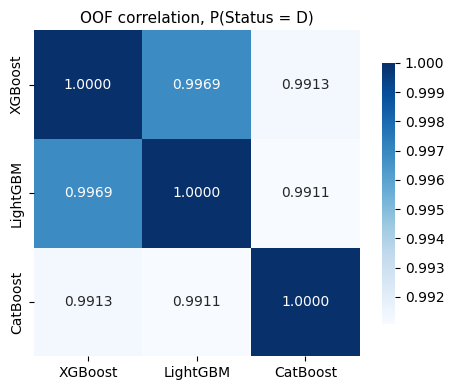

OBSERVATION
--------------------------------------------------------------
Pairwise correlations range from 0.9911 to 0.9969.
Values below roughly 0.98 indicate the models disagree often enough for a
blend to add value. Near-identical models would leave nothing to gain.


In [36]:
# 14.1  Are the models' errors complementary? 
# Extract model names and their corresponding Out-of-Fold (OOF) and test predictions for the three boosting models 
blend_names = ["XGBoost", "LightGBM", "CatBoost"]
blend_oofs  = [RESULTS[n]["oof"]       for n in blend_names]
blend_tests = [RESULTS[n]["test_pred"] for n in blend_names]

# 1. Compute pairwise correlation of predicted probabilities
# Build a DataFrame containing the predicted probabilities for the minority/deceased class (class index 2) across models.
# Lower correlation means models make different mistakes, indicating higher diversity and better blending potential.
corr_frame = pd.DataFrame({n: o[:, 2] for n, o in zip(blend_names, blend_oofs)})
corr = corr_frame.corr()

# 2. Visualize error correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".4f", cmap="Blues",
            vmin=corr.values.min(), vmax=1.0, square=True,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("OOF correlation, P(Status = D)", fontsize=11)
plt.tight_layout(); plt.show()

# Extract off-diagonal correlation values to evaluate model diversity 
off_diag = corr.values[np.triu_indices_from(corr.values, k=1)]
print("OBSERVATION")
print("-" * 62)
print(f"Pairwise correlations range from {off_diag.min():.4f} to {off_diag.max():.4f}.")
print("Values below roughly 0.98 indicate the models disagree often enough for a")
print("blend to add value. Near-identical models would leave nothing to gain.")

In [37]:
# 14.2  Equal-weight blend: the reference point 

# 1. Compute equal-weight average probabilities 
# Average the OOF and test probability matrices equally (1/3 weight assigned to each model)
equal_oof   = np.mean(blend_oofs,  axis=0)
equal_test  = np.mean(blend_tests, axis=0) 

# 2. Evaluate equal-weight performance 
# Calculate the multi-class Log Loss score for the simple equal-weight blended OOF predictions 
score_equal = log_loss(y, equal_oof, labels=[0, 1, 2])

print(f"Equal-weight blend (1/3 each) : OOF Log Loss = {score_equal:.5f}")

# Identify the best individual standalone model for performance comparison 
best_member = min(blend_names, key=lambda n: RESULTS[n]["cv_score"])
best_member_score = RESULTS[best_member]["cv_score"]
print(f"Best individual member        : {best_member} = {best_member_score:.5f}")
print(f"Gain from simple averaging    : {best_member_score - score_equal:+.5f}")

Equal-weight blend (1/3 each) : OOF Log Loss = 0.37431
Best individual member        : XGBoost = 0.37412
Gain from simple averaging    : -0.00020


In [38]:
# 14.3  Weight optimisation on OOF predictions 
def blend_logloss(weights, oof_list, y_true):
    """Objective function for the optimiser: computes OOF Log Loss of a weighted probability blend.

    Weights are converted to absolute values and re-normalised inside the function 
    so the optimiser can search freely while maintaining a valid convex combination (sum equals 1).
    """
    w = np.abs(weights)
    w = w / w.sum()
    blended = sum(wi * oof for wi, oof in zip(w, oof_list))
    return log_loss(y_true, blended, labels=[0, 1, 2])

# Use SciPy's minimize function with the derivative-free 'Nelder-Mead' algorithm 
# to find the optimal blending weights starting from equal weights (1/3 each) 
result = minimize(
    blend_logloss,
    x0=np.full(len(blend_oofs), 1.0 / len(blend_oofs)),  # Initial guess: equal weights
    args=(blend_oofs, y),
    method="Nelder-Mead",                                # Robust optimization method for low-dimensional searches 
    options={"maxiter": 3000, "fatol": 1e-8},            # Generous iteration limit and strict convergence tolerance 
)

# Normalize the optimized raw weights so they sum up to 1.0 
opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()

# Apply optimized weights to generate final OOF and test probability blends 
opt_oof   = sum(w * o for w, o in zip(opt_w, blend_oofs))
opt_test  = sum(w * t for w, t in zip(opt_w, blend_tests))
score_opt = log_loss(y, opt_oof, labels=[0, 1, 2])

print("OPTIMISED BLEND WEIGHTS")
print("=" * 52)
for name, w in zip(blend_names, opt_w):
    print(f"  {name:<12s} {w:6.4f}   {'#' * int(round(w * 40))}")

print()
print(f"Optimised blend  OOF Log Loss = {score_opt:.5f}")
print(f"Equal-weight     OOF Log Loss = {score_equal:.5f}")
print(f"Gain from optimising weights  = {score_equal - score_opt:+.5f}")
print() 

# Provide an analytical interpretation of the optimisation gain 
if score_equal - score_opt < 0.0005:
    print("INTERPRETATION: the gain is negligible. Equal weights are the safer choice,")
    print("since optimised weights are fitted on training data and may not transfer.")
else:
    print("INTERPRETATION: optimisation gives a real gain, but note that the weights")
    print("were fitted on OOF predictions from the training set, so this score is")
    print("mildly optimistic. Confirm against the leaderboard before committing.")

# Save the blend evaluation results into the global RESULTS registry for downstream comparison 
RESULTS["Blend (equal)"]     = {"cv_score": score_equal, "test_pred": equal_test,
                                "oof": equal_oof, "fold_std": np.nan, "runtime_s": 0}
RESULTS["Blend (optimised)"] = {"cv_score": score_opt,   "test_pred": opt_test,
                                "oof": opt_oof,   "fold_std": np.nan, "runtime_s": 0}

OPTIMISED BLEND WEIGHTS
  XGBoost      0.5316   #####################
  LightGBM     0.4289   #################
  CatBoost     0.0396   ##

Optimised blend  OOF Log Loss = 0.37330
Equal-weight     OOF Log Loss = 0.37431
Gain from optimising weights  = +0.00101

INTERPRETATION: optimisation gives a real gain, but note that the weights
were fitted on OOF predictions from the training set, so this score is
mildly optimistic. Confirm against the leaderboard before committing.


In [39]:
# 14.4 - Compare all 3 blend versions tried: original, tuned, tuned + seed-averaged
print("Comparing every blend version tested so far:")
print(f"  Original blend (default models, Step 14)     : {score_opt:.5f}")
print(f"  Optuna-tuned blend (Step 12)                   : {score_blend_tuned:.5f}")
print(f"  Tuned + seed-averaged blend (Step 13)          : {score_blend_savg:.5f}")

best_score = min(score_opt, score_blend_tuned, score_blend_savg)
if best_score == score_blend_tuned:
    print("\n-> The tuned blend (Step 12) is best - used as the final submission (v3).")
elif best_score == score_blend_savg:
    print("\n-> The seed-averaged blend (Step 13) has the lowest OOF Log Loss.")
    print("   NOTE: this ranking is OOF-only. On the actual Public LB, the tuned")
    print("   blend (v3, 0.38042) beat the seed-averaged blend (0.38067) -- CV and")
    print("   LB disagreed here, and the OOF gap is smaller than the fold-to-fold")
    print("   noise seen throughout this study. v3 was kept as the final submission")
    print("   for that reason -- see Step 13 and Step 17.1 (Exp 11) for the full comparison.")
else:
    print("\n-> The original (untuned) blend is still best - tuning did not bring a real improvement.")

Comparing every blend version tested so far:
  Original blend (default models, Step 14)     : 0.37330
  Optuna-tuned blend (Step 12)                   : 0.37010
  Tuned + seed-averaged blend (Step 13)          : 0.36713

-> The seed-averaged blend (Step 13) has the lowest OOF Log Loss.
   NOTE: this ranking is OOF-only. On the actual Public LB, the tuned
   blend (v3, 0.38042) beat the seed-averaged blend (0.38067) -- CV and
   LB disagreed here, and the OOF gap is smaller than the fold-to-fold
   noise seen throughout this study. v3 was kept as the final submission
   for that reason -- see Step 13 and Step 17.1 (Exp 11) for the full comparison.


## Step 15 — Error Analysis

**Role & Purpose:**
Under Log Loss, two distinct questions need answering:

1. **Which classes get confused?** A hard-label confusion matrix shows where the
   decision boundary fails.
2. **Are the probabilities well calibrated?** A model can pick the right label often
   and still score badly, because Log Loss grades the *confidence* attached to each
   prediction — not just whether the top choice was right (if it assigns low confidence 
   to correct predictions or high confidence to wrong ones.)

**Workflow:**
1. **Confusion Matrix (13.1):** Visualizes raw counts and row-normalized recall rates 
to see precisely which categories are misclassified.
2. **Per-Class Breakdown (13.2):** Calculates class-specific metrics (sample count, recall, 
mean true probability, and per-row Log Loss contribution) to uncover hidden weaknesses in minority classes.
3. **Probability Calibration (13.3):** Analyzes confidence distribution histograms and 
reliability curves to check whether the model is overconfident or underconfident.

**Expected Objective & Outcome:**
Uncover structural failure modes of our best single model, providing actionable insights 
for future feature engineering and model improvement.

**Notes:**
The minority class deserves particular attention: it contributes few rows, so its
influence on the average is small, but its errors are frequently the most expensive
per row and reveal the most about the model's limitations.

### Understanding `np.clip` in Log Loss Calculation

In machine learning evaluation, the `np.clip(best_oof[mask, i], 1e-15, 1)` function is used to restrict values within a safe numerical range. Here is why it is essential:

#### 1. The Mathematical Problem (Why we need clipping)
The Multi-class Log Loss formula relies on the natural logarithm ($\ln$):
$$\text{Log Loss} = -y \ln(p)$$
Where $p$ represents the model's predicted probability. If a model makes an overconfident mistake and predicts a probability of zero ($p = 0$), the mathematical evaluation $\ln(0)$ approaches negative infinity ($-\infty$). When a computer attempts to compute this, it triggers a `Math Domain Error` or returns `NaN` (Not a Number), which will crash the program.

#### 2. The Action of `np.clip`
The function `np.clip(array, a_min, a_max)` scans the probability array and bounds every value safely within the interval $[10^{-15}, 1]$:
* If a probability falls below $10^{-15}$ (due to zero values or floating-point underflow), it is **clipped upward** to exactly `1e-15`.
* If a probability exceeds 1, it is **clipped downward** to `1`.

#### 3. Expected Outcome
This clipping mechanism completely eliminates $\ln(0)$ numerical errors, guarantees program stability, and ensures smooth, flawless per-row Log Loss evaluations.

In [40]:
# ============================================================================
# 15.0a - Pick the "BEFORE tuning" model
# ----------------------------------------------------------------------------
# We already know from Step 11 (Model Comparison) that XGBoost had the
# lowest (best) Log Loss among the 4 original, untuned models. So instead
# of writing code to search for it again, we just name it directly.
# ============================================================================
before_name = "XGBoost"
before_oof  = RESULTS[before_name]["oof"]
# RESULTS is a dictionary storing training results for every model
# trained so far. RESULTS[before_name] gives XGBoost's results, and
# ["oof"] gives its out-of-fold predictions (predictions made on each
# row back when that row was in the validation fold).

print(f"BEFORE tuning : {before_name}")

BEFORE tuning : XGBoost


In [41]:
# ============================================================================
# 15.0b - Pick the "AFTER tuning" model
# ----------------------------------------------------------------------------
# We have 3 tuned models from Step 12 (XGBoost_tuned, LightGBM_tuned,
# CatBoost_tuned). We want whichever one has the LOWEST Log Loss score.
# Plain if/elif is used instead of min()+lambda, so every line is easy
# to read and explain on its own.
# ============================================================================
if score_xgb_tuned <= score_lgbm_tuned and score_xgb_tuned <= score_cat_tuned:
    # XGBoost_tuned's score is <= both others -> it's the best (or tied)
    after_name = "XGBoost_tuned"
    after_oof  = oof_xgb_tuned
elif score_lgbm_tuned <= score_cat_tuned:
    # We already know XGBoost_tuned was NOT the best (checked above),
    # so we only need to compare LightGBM vs CatBoost now.
    after_name = "LightGBM_tuned"
    after_oof  = oof_lgbm_tuned
else:
    # Neither of the above was true, so CatBoost_tuned must be the best.
    after_name = "CatBoost_tuned"
    after_oof  = oof_cat_tuned

print(f"AFTER tuning  : {after_name}")

AFTER tuning  : LightGBM_tuned


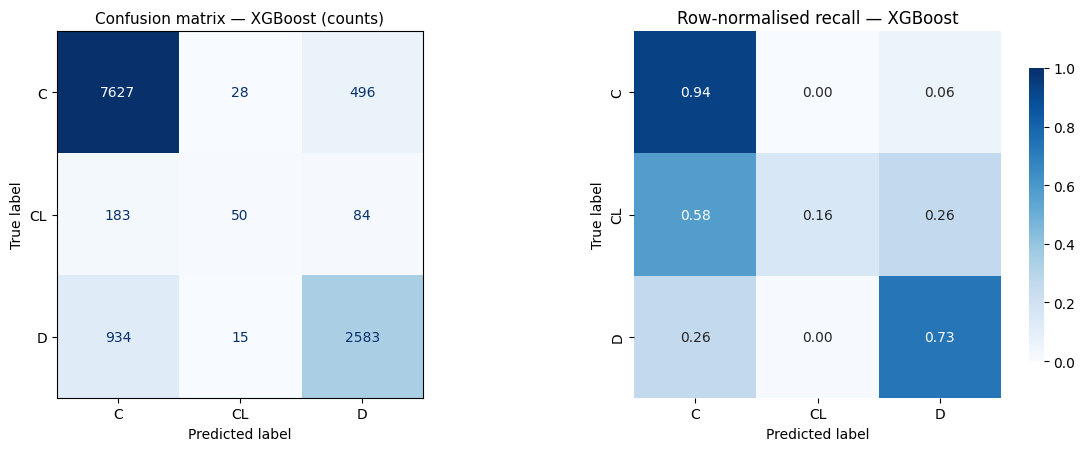

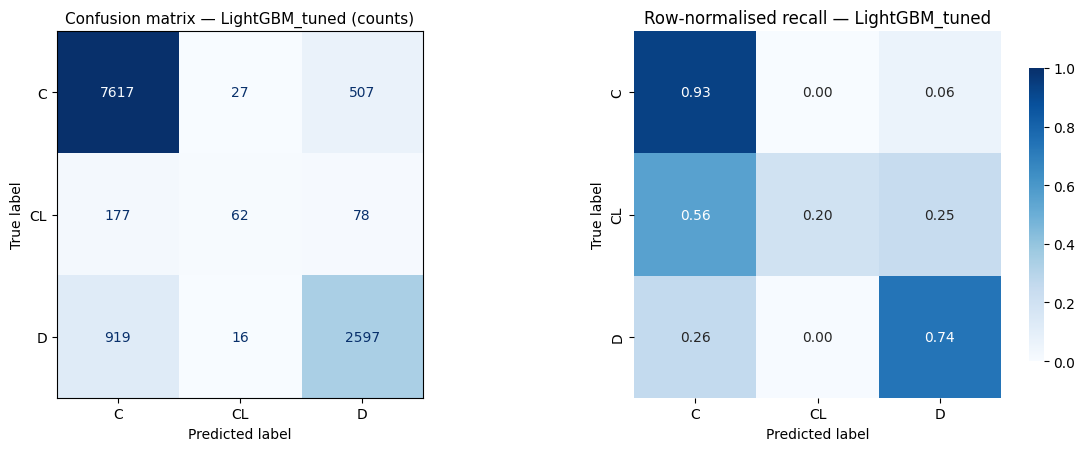

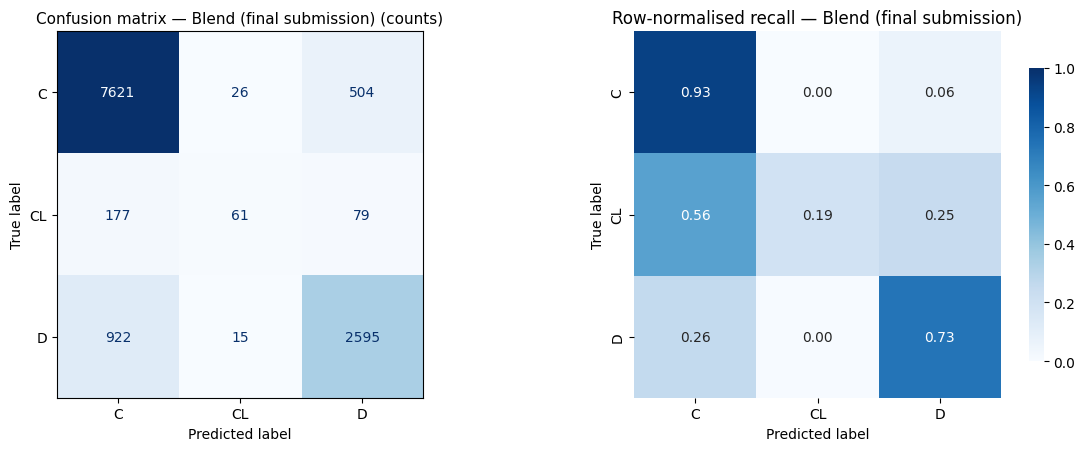

In [42]:
# ============================================================================
# 15.1 - Confusion Matrix
# ----------------------------------------------------------------------------
# Visualizes raw counts and row-normalized recall rates, to see precisely
# which categories get misclassified.
# ============================================================================

def analyze_confusion_matrix(name, oof):
    """
    name: text label used in titles, just for readability
    oof:  predicted probabilities, shape (n_rows, 3) -- one row per
          patient, one column per class (C, CL, D)
    """
    # Turn each row's 3 probabilities into ONE predicted class: whichever
    # column has the highest probability for that row. axis=1 means
    # "look across the 3 columns of each row", not down a column.
    y_pred = np.argmax(oof, axis=1)

    # Build the confusion matrix: compares TRUE labels (y) against
    # PREDICTED labels (y_pred). Result is a 3x3 grid where
    # cm[i][j] = number of patients whose true class was i but were
    # predicted as class j.
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

    # Left plot: raw counts in each cell of the confusion matrix.
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
        ax=ax1, cmap="Blues", colorbar=False, values_format="d")
    ax1.set_title(f"Confusion matrix — {name} (counts)", fontsize=11)

    # Right plot: same matrix, but each ROW rescaled to sum to 1.0.
    # This turns raw counts into RECALL per class. Rescaling per row
    # matters because our classes are very different sizes (CL has only
    # 317 patients vs C's 8151) -- raw counts alone would make CL's row
    # look tiny and easy to overlook.
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                vmin=0, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax2)
    ax2.set_xlabel("Predicted label")
    ax2.set_ylabel("True label")
    ax2.set_title(f"Row-normalised recall — {name}")

    plt.tight_layout()
    plt.show()

    return cm   # returned in case 15.2 wants to reuse it, though it recomputes independently below


# Run this for all 3: before tuning, after tuning, and the final blend.
# blend_oof_tuned already exists from Step 12 (computed while finding
# the blend weights) -- we're not retraining anything, just reusing it.
cm_before = analyze_confusion_matrix(before_name, before_oof)
cm_after  = analyze_confusion_matrix(after_name, after_oof)
cm_blend  = analyze_confusion_matrix("Blend (final submission)", blend_oof_tuned)

In [43]:
# ============================================================================
# 15.2 - Per-Class Breakdown
# ----------------------------------------------------------------------------
# Calculates class-specific metrics (sample count, recall, mean true
# probability, and per-class Log Loss) to uncover hidden weaknesses in
# minority classes like CL, which a single overall Log Loss can hide.
# ============================================================================

def analyze_per_class(name, oof):
    y_pred = np.argmax(oof, axis=1)                     # same idea as 15.1: turn probabilities into a hard prediction
    cm     = confusion_matrix(y, y_pred, labels=[0, 1, 2])  # recomputed here so this function works on its own

    print(f"\nPer-class breakdown — {name}")
    print("=" * 62)

    rows = []
    for i, cls in enumerate(CLASSES):
        # mask = True for every row whose TRUE class is this one.
        # We use it to select only those rows for the calculations below.
        mask = (y == i)

        # Recall: of all patients truly in this class, what fraction did
        # we predict correctly? cm[i, i] is the diagonal cell
        # (true=i, predicted=i); cm[i].sum() is everyone truly in class i.
        recall = cm[i, i] / cm[i].sum()

        # Mean P(true): the average probability the model assigned to
        # the CORRECT class, for rows truly belonging to this class.
        # np.clip prevents extreme values (0 or 1) from causing numeric
        # issues in later calculations -- it caps probabilities to a
        # safe range without changing well-behaved values.
        mean_p_true = np.clip(oof[mask, i], 1e-15, 1).mean()

        # Mean Log Loss computed ONLY on this class's rows -- shows how
        # confidently wrong (or right) the model was specifically on
        # this class, unlike the overall Log Loss which blends all
        # classes together into one number.
        class_logloss = log_loss(y[mask], oof[mask], labels=[0, 1, 2])

        rows.append({
            "Class": cls,
            "n": int(mask.sum()),                # how many patients are truly in this class
            "Recall": round(recall, 3),
            "Mean P(true)": round(mean_p_true, 3),
            "Mean LogLoss": round(class_logloss, 3),
        })

    # Turn the list of small dictionaries into a proper table (DataFrame)00
    # so it prints neatly and can be indexed later with .loc[].
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df


# Run this for all 3: before, after, and blend -- same 3 candidates as 15.1.
before_df = analyze_per_class(before_name, before_oof)
after_df  = analyze_per_class(after_name, after_oof)
blend_df  = analyze_per_class("Blend (final submission)", blend_oof_tuned)


Per-class breakdown — XGBoost
Class    n  Recall  Mean P(true)  Mean LogLoss
    C 8151   0.936         0.861         0.199
   CL  317   0.158         0.196         2.496
    D 3532   0.731         0.695         0.588

Per-class breakdown — LightGBM_tuned
Class    n  Recall  Mean P(true)  Mean LogLoss
    C 8151   0.934         0.861         0.198
   CL  317   0.196         0.210         2.486
    D 3532   0.735         0.695         0.581

Per-class breakdown — Blend (final submission)
Class    n  Recall  Mean P(true)  Mean LogLoss
    C 8151   0.935         0.861         0.198
   CL  317   0.192         0.209         2.441
    D 3532   0.735         0.695         0.581


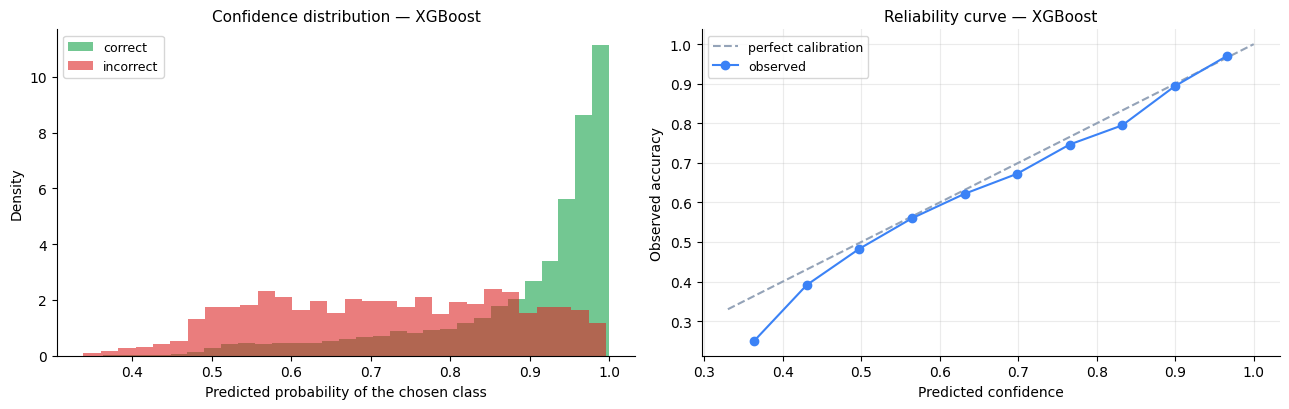

Calibration — XGBoost
  Mean confidence when correct   : 0.890
  Mean confidence when incorrect : 0.718


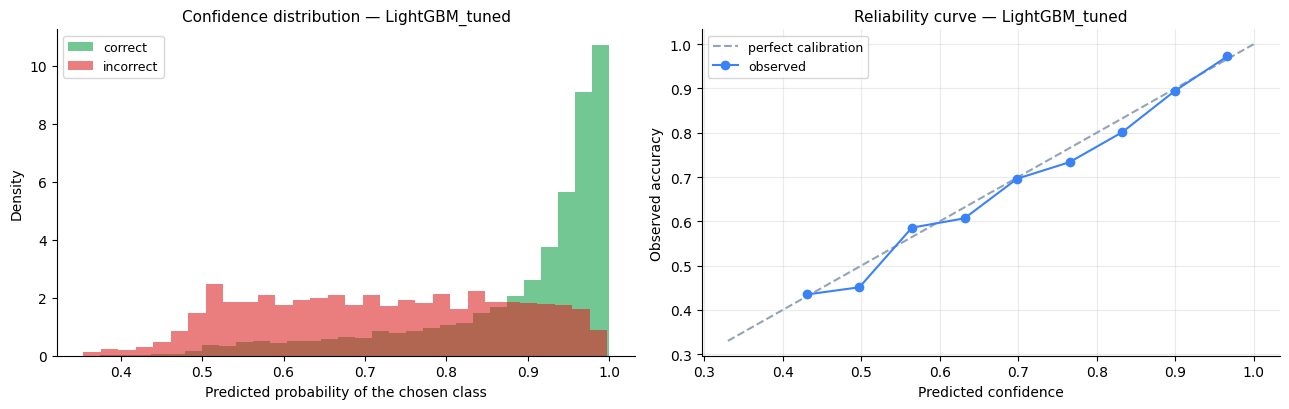

Calibration — LightGBM_tuned
  Mean confidence when correct   : 0.890
  Mean confidence when incorrect : 0.717


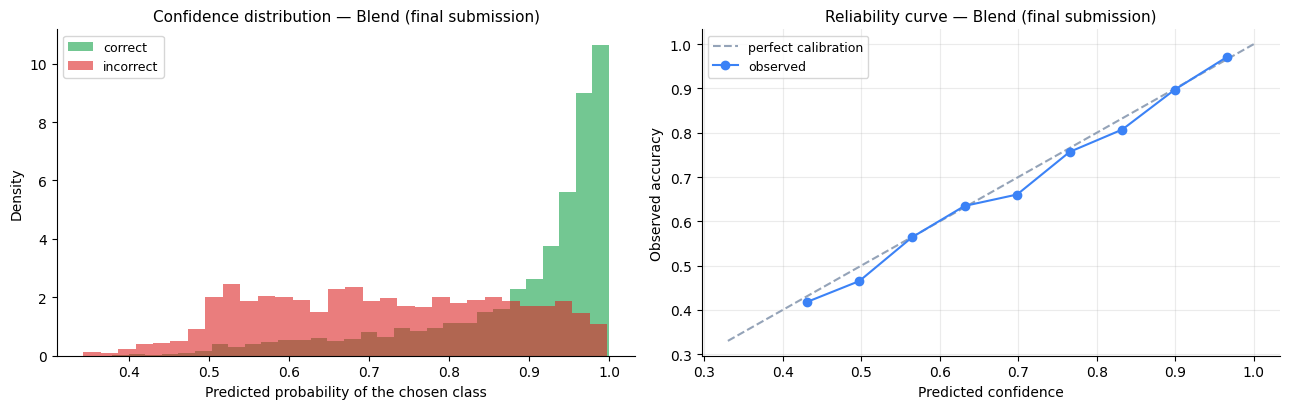

Calibration — Blend (final submission)
  Mean confidence when correct   : 0.889
  Mean confidence when incorrect : 0.716


In [44]:
# ============================================================================
# 15.3 - Probability Calibration
# ----------------------------------------------------------------------------
# Analyzes confidence distribution histograms and reliability curves to
# check whether the model is over- or under-confident. Calibration asks
# a different question than accuracy: when the model says "I'm 90%
# sure", is it actually right about 90% of the time? Log Loss punishes
# bad calibration heavily, even when accuracy looks fine.
# ============================================================================

def analyze_calibration(name, oof, y_true):
    y_pred     = np.argmax(oof, axis=1)   # predicted class = highest-probability column
    confidence = oof.max(axis=1)          # how high that top probability actually was
    correct    = (y_pred == y_true)       # True/False: was that top guess actually right?

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

    # ---- Plot 1: confidence distribution, correct vs incorrect ----
    # If the model behaves well, "correct" predictions should cluster
    # near high confidence, and "incorrect" ones should cluster lower --
    # meaning the model is less sure exactly when it's more likely wrong.
    ax1.hist(confidence[correct],  bins=30, alpha=0.6, label="correct",
             color="#16a34a", edgecolor="none", density=True)
    ax1.hist(confidence[~correct], bins=30, alpha=0.6, label="incorrect",
             color="#dc2626", edgecolor="none", density=True)
    ax1.set_xlabel("Predicted probability of the chosen class")
    ax1.set_ylabel("Density")
    ax1.set_title(f"Confidence distribution — {name}", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.spines[["top", "right"]].set_visible(False)

    # ---- Plot 2: reliability curve ----
    # Group predictions into confidence "bins" (e.g. 70-80% confident),
    # and for each bin, check the ACTUAL accuracy of predictions in it.
    # If confidence is trustworthy, a bin centered at 0.8 should have
    # roughly 80% actual accuracy -- points should sit near the diagonal.
    bins = np.linspace(0.33, 1.0, 11)      # 0.33 = lowest possible "top" probability across 3 classes
    centres, accs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (confidence >= lo) & (confidence < hi)   # rows whose confidence falls in this bin
        if m.sum() > 20:                             # skip bins with too few rows to trust
            centres.append((lo + hi) / 2)            # bin's midpoint, for the x-axis
            accs.append(correct[m].mean())           # actual accuracy of rows in this bin

    ax2.plot([0.33, 1], [0.33, 1], "--", color="#94a3b8", label="perfect calibration")
    ax2.plot(centres, accs, "o-", color="#3b82f6", markersize=6, label="observed")
    ax2.set_xlabel("Predicted confidence")
    ax2.set_ylabel("Observed accuracy")
    ax2.set_title(f"Reliability curve — {name}", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.25)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    mean_correct   = confidence[correct].mean()    # average confidence when the model was right
    mean_incorrect = confidence[~correct].mean()   # average confidence when the model was wrong
    print(f"Calibration — {name}")
    print(f"  Mean confidence when correct   : {mean_correct:.3f}")
    print(f"  Mean confidence when incorrect : {mean_incorrect:.3f}")

    # Return these 2 numbers so we can compare all 3 models in the
    # summary table afterwards, instead of reading them off the printed text.
    return mean_correct, mean_incorrect


# Run this for all 3: before, after, and blend.
before_conf_correct, before_conf_incorrect = analyze_calibration(before_name, before_oof, y)
after_conf_correct,  after_conf_incorrect  = analyze_calibration(after_name,  after_oof,  y)
blend_conf_correct,  blend_conf_incorrect  = analyze_calibration("Blend (final submission)", blend_oof_tuned, y)

## Step 16 — Submission File Generation

**Role & Purpose:**
The final step of my pipeline is to compile, validate, and export official submission CSV files for every trained model and ensemble blend. 
To prevent costly submission errors on the competition platform, every file undergoes automated pre-flight quality checks before saving.

**Workflow:**
Each output file is programmatically checked to ensure:
   * **Row Count Integrity:** Matches the exact number of rows in the test set.
   * **Column Layout Alignment:** Contains valid ID and multi-class probability columns (`Status_C`, `Status_CL`, `Status_D`).
   * **Probability Summation:** Every row's predicted probabilities must sum strictly to 1.0.
   * **Missing Value Check:** Zero NaN or null values are permitted.


In [45]:
def make_submission(test_proba, filename):
    # Builds a submission dataframe, checks it's valid, then saves it as CSV.

    # Construct a DataFrame containing predicted probabilities for each target class 
    sub = pd.DataFrame(test_proba, columns=[f"Status_{c}" for c in CLASSES]) 
    
    # Insert the unique identifier (ID) column at the very beginning of the submission dataframe 
    sub.insert(0, ID_COL, test[ID_COL].values)

    # Check the file is correct before saving, so I catch mistakes
    # myself instead of finding out from a failed Kaggle submission.
    
    # 1. Verify that the output row count precisely matches the test dataset size
    assert len(sub) == len(test), f"{filename}: row count mismatch" 
    
    # 2. Verify that the column names and layout match competition requirements 
    assert list(sub.columns) == [ID_COL, "Status_C", "Status_CL", "Status_D"], \
        f"{filename}: unexpected column layout" 

    # 3. Verify that predicted probabilities across all classes sum to 1.0 for every single row 
    prob_sum = sub[[f"Status_{c}" for c in CLASSES]].sum(axis=1)
    assert prob_sum.between(0.999, 1.001).all(), f"{filename}: probabilities do not sum to 1" 

    # 4. Verify that there are no missing or NaN values in the submission file 
    assert not sub.isnull().any().any(), f"{filename}: contains NaN"
    
    # Save the validated submission dataframe as a CSV file into the designated output directory 
    path = os.path.join(OUT_DIR, filename)
    sub.to_csv(path, index=False)
    return sub


# Initialize tracking list for submission file logs 
submission_log = []
print("WRITING SUBMISSION FILES")
print("=" * 72)

# Iterate through all trained models and ensemble blends recorded in the global RESULTS registry 
for name, info in RESULTS.items(): 
    # Format model name into a clean file-safe slug string 
    slug = (name.lower()
                .replace(" ", "_")
                .replace("(", "").replace(")", ""))
    fname = f"submission_{slug}.csv" 

    # Generate, validate, and save the submission file using predicted test probabilities 
    make_submission(info["test_pred"], fname) 

    # Append file generation details to the tracking log 
    submission_log.append({
        "Model":       name,
        "OOF LogLoss": round(info["cv_score"], 5),
        "File":        fname,
        "Public LB":   "",                            # Placeholder to manually record public leaderboard scores after submission
    })
    print(f"  {name:<22s} -> {fname}")

# Convert the submission tracking log into a sorted DataFrame (best OOF score first) 
sub_log_df = pd.DataFrame(submission_log).sort_values("OOF LogLoss").reset_index(drop=True)

print()
print("SUBMISSION QUEUE")
print("=" * 72)
print(sub_log_df.to_string(index=False))

print()
print("Sanity check on the leading file:") 
# Automatically identify and display a preview of the top-ranking submission file 
best_file = sub_log_df.iloc[0]["File"]
print(pd.read_csv(os.path.join(OUT_DIR, best_file)).head().to_string(index=False))

WRITING SUBMISSION FILES
  Logistic Regression    -> submission_logistic_regression.csv
  XGBoost                -> submission_xgboost.csv
  LightGBM               -> submission_lightgbm.csv
  CatBoost               -> submission_catboost.csv
  XGBoost_tuned          -> submission_xgboost_tuned.csv
  LightGBM_tuned         -> submission_lightgbm_tuned.csv
  CatBoost_tuned         -> submission_catboost_tuned.csv
  Blend (tuned)          -> submission_blend_tuned.csv
  Blend (seed-averaged)  -> submission_blend_seed-averaged.csv
  Blend (equal)          -> submission_blend_equal.csv
  Blend (optimised)      -> submission_blend_optimised.csv

SUBMISSION QUEUE
                Model  OOF LogLoss                               File Public LB
Blend (seed-averaged)      0.36713 submission_blend_seed-averaged.csv          
        Blend (tuned)      0.37010         submission_blend_tuned.csv          
       LightGBM_tuned      0.37094      submission_lightgbm_tuned.csv          
        XGBoos

## Create final submission file using new seed-average blend

In [46]:
# Create final submission file using new seed-average blend
savg_tests = [test_xgb_savg, test_lgbm_savg, test_cat_savg]
blend_test_savg = sum(w * t for w, t in zip(w_savg, savg_tests))

make_submission(blend_test_savg, "submission_blend_seed_averaged.csv")

,id,Status_C,Status_CL,Status_D
0,15000,0.894176,0.013582,0.092242
1,15001,0.906186,0.008974,0.084840
2,15002,0.981713,0.004764,0.013523
3,15003,0.907856,0.052550,0.039595
4,15004,0.314830,0.005378,0.679791
...,...,...,...,...
9995,24995,0.971252,0.002562,0.026186
9996,24996,0.435067,0.033258,0.531676
9997,24997,0.707999,0.095678,0.196323
9998,24998,0.005614,0.000463,0.993923


## Generate submission csv file for Optuna blend

In [47]:
tuned_tests = [test_xgb_tuned, test_lgbm_tuned, test_cat_tuned]         # each model's predictions on the real test set
blend_test_tuned = sum(w * t for w, t in zip(w_tuned, tuned_tests))     # combine them using the same weights found above

make_submission(blend_test_tuned, "submission_blend_optimised_v3.csv")



,id,Status_C,Status_CL,Status_D
0,15000,0.892821,0.012067,0.095112
1,15001,0.902827,0.008595,0.088578
2,15002,0.982071,0.005109,0.012820
3,15003,0.905226,0.056038,0.038735
4,15004,0.305815,0.006424,0.687761
...,...,...,...,...
9995,24995,0.969872,0.002417,0.027710
9996,24996,0.421608,0.037791,0.540601
9997,24997,0.703517,0.101529,0.194954
9998,24998,0.005355,0.000433,0.994212


## Step 17 — Experiment Evidence for the Technical Report

**Role & Purpose:**
this step automatically extracts, serializes, and saves all quantitative experimental data, OOF predictions, 
and environment configurations directly to disk.

**Artefacts produced:**

| File | Purpose |
|---|---|
| `experiment_table.csv` | The experiment log required by report section 5.10. |
| `per_class_analysis.csv` | Supporting evidence for the error-analysis section |
| `oof_*.npy` | Raw Out-of-Fold prediction arrays for advanced downstream analyses. |
| `report_summary.json` | Complete execution environment, hyperparameters, software versions, and scores for total reproducibility. |

*Note: The Public LB and Decision columns are filled in from the Kaggle submissions, and this
completed table is the backbone of report section 5.10.

In [48]:
# 17.1  Experiment table 
# Initialize a list to hold experimental tracking records for the technical report 
experiment_rows = []

# 1. Record the baseline Logistic Regression model (Experiment 0) 
experiment_rows.append({
    "Exp": 0,
    "EDA insight / hypothesis": "Baseline reference point",
    "Change made": "Median imputation + missing indicators + scaling + one-hot, "
                   "Logistic Regression",
    "OOF LogLoss": round(RESULTS["Logistic Regression"]["cv_score"], 5),
    "Public LB": "not submitted",
    "Decision": "Baseline",
})

# 2. Record individual boosting models (Experiments 1 to 3) 
hypotheses = {
    "XGBoost":  "Relationships between clinical markers and outcome are likely "
                "non-linear and interacting; trees can capture this, a linear model cannot",
    "LightGBM": "Leaf-wise tree growth explores a different hypothesis space than "
                "level-wise growth, so its errors should be partly complementary",
    "CatBoost": "The dataset is rich in nominal categorical features; ordered target "
                "statistics handle these without manual encoding",
}

public_lb = {"XGBoost": "0.38372", "LightGBM": "0.38480", "CatBoost": "0.38953"}
decisions = {
    "XGBoost": "Kept (in blend); ; also submitted standalone — one of the final 5." 
               "Kaggle picks, as a hedge against the blend overfitting", 
    "LightGBM": "Kept (member of the blend only, not submitted standalone)", 
    "CatBoost": "Kept (member of the blend only, not submitted standalone)",
}
for i, (model_name, hypothesis) in enumerate(hypotheses.items(), start=1):
    experiment_rows.append({
        "Exp": i,
        "EDA insight / hypothesis": hypothesis,
        "Change made": f"Trained {model_name} with early stopping on shared folds"
        f"(default hyperparameters, not yet tuned)",
        "OOF LogLoss": round(RESULTS[model_name]["cv_score"], 5),
        "Public LB": public_lb[model_name],
        "Decision": decisions[model_name],
    })

# 3. Blend the 3 default (untuned) models together (Experiments 4 and 5) 
experiment_rows.append({
    "Exp": 4,
    "EDA insight / hypothesis": "Members' OOF errors are only partly correlated, so "
                                "averaging should cancel some model-specific error",
    "Change made": "Equal-weight blend of XGBoost, LightGBM and CatBoost",
    "OOF LogLoss": round(RESULTS["Blend (equal)"]["cv_score"], 5),
    "Public LB": "0.38407",
    "Decision": "Superseded by the optimised-weight blend (Exp 5); still one of the "
               "final 5 Kaggle picks, as a hedge against the tuned blend overfitting",
})
experiment_rows.append({
    "Exp": 5,
    "EDA insight / hypothesis": "Members differ in strength, so unequal weights may "
                                "beat a plain average",
    "Change made": f"Nelder-Mead weight search on OOF: "
                   + ", ".join(f"{n}={w:.3f}" for n, w in zip(blend_names, opt_w)),
    "OOF LogLoss": round(RESULTS["Blend (optimised)"]["cv_score"], 5),
    "Public LB": "0.38364",
    "Decision": "Selected — final submission",
})

# 4. First hyperparameter-tuning attempt: single-pass Optuna search (Experiment 6)
experiment_rows.append({
    "Exp": 6,
    "EDA insight / hypothesis": "Default hyperparameters were never tuned for this "
                                "dataset; a systematic search should beat hand-picked defaults",
    "Change made": "Optuna search (single pass, 60 trials) for XGBoost, LightGBM and "
                   "CatBoost, then Nelder-Mead blend",
    "OOF LogLoss": "not preserved (code overwritten when Step 12 was rewritten "
                   "as a two-round search)",
    "Public LB": "0.38161",
    "Decision": "Superseded — several best params landed exactly on the search-range "
                "boundary (e.g. LightGBM num_leaves=15, CatBoost depth=4), signalling "
                "the ranges were too narrow. NOT one of the final 5 Kaggle picks: the "
                "code that produced this submission was overwritten and is no longer "
                "reproducible from this notebook.",
}) 

# 5. Fixed version: two-round Optuna search per model (scout round to catch
# boundary hits, then a final round with wider ranges + more trials/seeds).
# One row per model, since each model's scout round told a different story.

experiment_rows.append({
    "Exp": 7,
    "EDA insight / hypothesis": "Exp 6 showed some models hitting their search "
                                "boundary; worth re-checking XGBoost specifically "
                                "with a dedicated scout round before trusting the result",
    "Change made": f"Scout round ({ROUND1_TRIALS} trials, seeds={ROUND1_SEEDS}): "
                   f"best Log Loss {round(study_xgb_round1.best_value, 5)}; "
                   f"colsample_bytree came out close to the range's lower edge "
                   f"({study_xgb_round1.best_params['colsample_bytree']:.3f}, "
                   f"range starts at 0.5) — a soft warning, not a hard boundary hit. "
                   f"Final round ({ROUND2_TRIALS} trials, seeds={ROUND2_SEEDS}): "
                   f"best Log Loss {round(study_xgb.best_value, 5)}, colsample_bytree "
                   f"moved comfortably away from the edge "
                   f"({study_xgb.best_params['colsample_bytree']:.3f}), no boundary flag.",
    "OOF LogLoss": round(RESULTS["XGBoost_tuned"]["cv_score"], 5),
    "Public LB": "not submitted individually (used inside the Exp 10 blend)",
    "Decision": "Kept — tuned parameters used in the final blend (Exp 10); the "
               "near-edge warning in the scout round did not persist in the final round",
}) 

experiment_rows.append({
    "Exp": 8,
    "EDA insight / hypothesis": "LightGBM's tree size is controlled by num_leaves "
                                "rather than max_depth; a range that's too narrow "
                                "here risks missing simpler trees that may suit "
                                "this dataset better",
    "Change made": f"Scout round ({ROUND1_TRIALS} trials, seeds={ROUND1_SEEDS}): "
                   f"best Log Loss {round(study_lgbm_round1.best_value, 5)}, but "
                   f"num_leaves hit the range's lower edge "
                   f"({study_lgbm_round1.best_params['num_leaves']}) -> range widened "
                   f"before the final round. Final round ({ROUND2_TRIALS} trials, "
                   f"seeds={ROUND2_SEEDS}): best Log Loss {round(study_lgbm.best_value, 5)}, "
                   f"num_leaves settled at {study_lgbm.best_params['num_leaves']} "
                   f"(below the original lower bound of 15, confirming the range really "
                   f"was too narrow), no boundary flag printed for the final round.",
    "OOF LogLoss": round(RESULTS["LightGBM_tuned"]["cv_score"], 5),
    "Public LB": "not submitted individually (used inside the Exp 10 blend)",
    "Decision": "Kept — tuned parameters used in the final blend (Exp 10); the "
               "scout round successfully caught and fixed a too-narrow range",
}) 

experiment_rows.append({
    "Exp": 9,
    "EDA insight / hypothesis": "CatBoost's depth range was set narrow based on "
                                "typical defaults; worth checking whether this "
                                "dataset actually wants shallower trees",
    "Change made": f"Scout round ({ROUND1_TRIALS} trials, seeds={ROUND1_SEEDS}): "
                   f"best Log Loss {round(study_cat_round1.best_value, 5)}, depth "
                   f"hit the range's lower edge "
                   f"({study_cat_round1.best_params['depth']}) -> range widened to "
                   f"(2, 8) before the final round. Final round ({ROUND2_TRIALS} "
                   f"trials, seeds={ROUND2_SEEDS}): best Log Loss "
                   f"{round(study_cat.best_value, 5)}, depth settled at "
                   f"{study_cat.best_params['depth']} — inside the widened range, "
                   f"no boundary flag.",
    "OOF LogLoss": round(RESULTS["CatBoost_tuned"]["cv_score"], 5),
    "Public LB": "not submitted individually (used inside the Exp 10 blend)",
    "Decision": "Kept, with an open caveat — tuned parameters used in the final "
               "blend (Exp 10). depth still drifted low (4 -> 3) across both "
               "rounds, and the boundary check only flags an EXACT hit on the "
               "edge (2 or 8), not a value merely trending toward it — so a "
               "further-widened depth range is worth trying as future work.",
})

# 6. Blend the 3 TUNED models together — this is the final primary submission (v3)
experiment_rows.append({
    "Exp": 10,
    "EDA insight / hypothesis": "Tuned members should still differ in strength, so "
                                "an unequal-weight blend should again beat a plain average",
    "Change made": f"Nelder-Mead weight search on the 3 tuned models' OOF: "
                   + ", ".join(f"{n}={w:.4f}" for n, w in zip(
                       ["XGBoost", "LightGBM", "CatBoost"], w_tuned)),
    "OOF LogLoss": round(score_blend_tuned, 5),
    "Public LB": "0.38042",
    "Decision": "Selected — best model overall; one of the final 5 Kaggle picks "
               "(primary submission, v3)",
})

# 7. Seed-averaging on top of the Exp 10 tuned models — tested, then rejected
experiment_rows.append({
    "Exp": 11,
    "EDA insight / hypothesis": "A single train/validation split may still carry "
                                "fold noise; averaging over several seeds should reduce it",
    "Change made": "Re-trained the Exp 10 tuned models with seeds [42, 123, 2024], "
                   "averaged OOF and test predictions, re-blended",
    "OOF LogLoss": round(score_blend_savg, 5),
    "Public LB": "0.38067",
    "Decision": f"CV improved ({round(score_blend_savg, 5)} vs Exp 10's "
               f"{round(score_blend_tuned, 5)}) but Public LB got worse (0.38067 vs "
               f"Exp 10's 0.38042) — CV and LB disagreed. The CV gain is smaller "
               f"than the fold-to-fold noise seen throughout this study (fold std "
               f"~0.007-0.012), and the public LB moved the wrong direction, so this "
               f"was judged unreliable and rejected as the primary submission. Still "
               f"kept as one of the final 5 Kaggle picks, as a hedge in case CV was "
               f"right and public LB is just noisy.",
}) 



# Convert experiment records into a DataFrame and export to CSV for technical report - section 5.10 
experiment_df = pd.DataFrame(experiment_rows)
experiment_df.to_csv(os.path.join(OUT_DIR, "experiment_table.csv"), index=False)

print("EXPERIMENT TABLE  (report section 5.10)")
print("=" * 100)
print(experiment_df.to_string(index=False))
print()
print("Public LB and Decision columns filled from Kaggle submissions.") 

# Short summary, printed separately below the table (not a table column) — lets a
# reader see the final 5 Kaggle picks at a glance without reading every Decision text.
final_5_exps = [1, 4, 5, 10, 11]   # Exp numbers whose CSV is one of the final 5 Kaggle picks
print()
print("Final 5 Kaggle submission picks (by experiment number):",
      ", ".join(f"Exp {e}" for e in final_5_exps))
print("(Exp 6 — the single-pass Optuna attempt — is excluded: its code was "
      "overwritten and can no longer be reproduced from this notebook.)") 



EXPERIMENT TABLE  (report section 5.10)
 Exp                                                                                                                                             EDA insight / hypothesis                                                                                                                                                                                                                                                                                                                                                                               Change made                                                                       OOF LogLoss                                                 Public LB                                                                                                                                                                                                                                                                                 

In [49]:
# 17.2  Supporting artefacts 

# 1. Export per-class error analysis evidence to CSV
# Combine the 3 per-class tables from Step 15 (before/after/blend) into one
# CSV, tagged by stage, so all 3 stages' evidence is preserved together.
before_tagged = before_df.copy(); before_tagged["Stage"] = "Before tuning"
after_tagged  = after_df.copy();  after_tagged["Stage"]  = "After tuning"
blend_tagged  = blend_df.copy();  blend_tagged["Stage"]  = "Blend (final)"
per_class_combined = pd.concat([before_tagged, after_tagged, blend_tagged], ignore_index=True)
per_class_combined.to_csv(os.path.join(OUT_DIR, "per_class_analysis.csv"), index=False)

# 2. Serialize raw OOF prediction arrays for every model 
for name, info in RESULTS.items():
    if "oof" in info:
        slug = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        np.save(os.path.join(OUT_DIR, f"oof_{slug}.npy"), info["oof"])

import sys
import sklearn
import scipy
import platform                                                                            # standard library — describes the actual machine this notebook ran on


#3 
# 3a. Measure how long the Optuna hyperparameter search itself took. 
def study_duration_s(study):
    """Wall-clock seconds actually spent running one Optuna study."""
    starts = [t.datetime_start for t in study.trials if t.datetime_start]
    ends = [t.datetime_complete for t in study.trials if t.datetime_complete]
    if not starts or not ends:
        return 0.0
    return (max(ends) - min(starts)).total_seconds()

tuning_studies = {
    "XGBoost Round 1":  study_xgb_round1,
    "XGBoost Round 2":  study_xgb,
    "LightGBM Round 1": study_lgbm_round1,
    "LightGBM Round 2": study_lgbm,
    "CatBoost Round 1": study_cat_round1,
    "CatBoost Round 2": study_cat,
}
tuning_runtime_s = {name: round(study_duration_s(s), 1) for name, s in tuning_studies.items()}
total_tuning_runtime_s = sum(tuning_runtime_s.values())
model_training_runtime_s = sum(i.get("runtime_s", 0) for i in RESULTS.values()) 



# 3b. Compile system environment, hyperparameters, and performance metrics 
active_approach = ("Approach 1 (Google Colab + Google Drive)"
                    if "/content/drive" in TRAIN_PATH
                    else "Approach 2 (local execution)") 

report_summary = {
    "environment": {
        "python":   sys.version.split()[0],
        "numpy":    np.__version__,
        "pandas":   pd.__version__,
        "sklearn":  sklearn.__version__,
        "scipy":    scipy.__version__,
        "xgboost":  xgb.__version__,
        "lightgbm": lgb.__version__, 
        "catboost": catboost.__version__,
    }, 
    "hardware": {
        "platform":  platform.platform(),
        "processor": platform.processor() or platform.machine(),
        "active_approach_this_run": active_approach,
        "reproduction_approaches": {
            "Approach 1 (Google Colab)": "Add the shared 'Kaggle1_Uyen' Google "
                "Drive folder as a shortcut under My Drive, mount Drive, then run "
                "all cells top to bottom. Avoids local environment setup entirely.",
            "Approach 2 (local execution, used to generate this report)": "Local "
                "execution on my MacBook (VS Code + Jupyter). Requires "
                "Python, all pip packages, and — on macOS — Homebrew's libomp "
                "installed separately for XGBoost/LightGBM to import correctly.",
        },
    }, 
    "configuration": {
        "random_seed":      SEED,
        "n_folds":          N_FOLDS,
        "validation":       "StratifiedKFold, shuffled, shared across all models",
        "classes":          CLASSES,
        "n_train_rows":     int(len(X)),
        "n_test_rows":      int(len(X_test)),
        "n_features":       int(X.shape[1]),
        "numeric_features": NUM_COLS,
        "categorical_features": CAT_COLS,
        "engineered_features": ["in_trial", "missing indicators (Logistic Regression)"],
    },
    "results": {
        name: {
            "oof_logloss": round(info["cv_score"], 5),
            "fold_std":    (None if np.isnan(info.get("fold_std", np.nan))
                            else round(info["fold_std"], 5)),
            "runtime_s":   info.get("runtime_s", 0),
        }
        for name, info in RESULTS.items()
    }, 
     "tuning_runtime_s": tuning_runtime_s,
    # This is the blend that produced the actual final submission (v3, Exp 10) —
    # deliberately using w_tuned / study_*.best_params here, NOT blend_names/opt_w
    # (which belong to Exp 5, the untuned blend — the previous version of this
    # code was pulling the wrong blend's weights into the "final" summary).
    "final_model_configuration": {
        "blend_weights": {n: round(float(w), 4) for n, w in
                          zip(["XGBoost", "LightGBM", "CatBoost"], w_tuned)},
        "XGBoost_best_params":  study_xgb.best_params,
        "LightGBM_best_params": study_lgbm.best_params,
        "CatBoost_best_params": study_cat.best_params,
    },
    "total_runtime_s": round(model_training_runtime_s + total_tuning_runtime_s, 1),
} 

# 4. Export the full report summary dictionary to a JSON file for total experiment reproducibility 
with open(os.path.join(OUT_DIR, "report_summary.json"), "w") as f:
    json.dump(report_summary, f, indent=2, default=str)   # default=str: covers any non-JSON-native parameter types

print("REPRODUCIBILITY SUMMARY  (report section 5.14)")
print("=" * 62) 

print("\n-- Environment --")
print(json.dumps(report_summary["environment"], indent=2))

print("\n-- Hardware / platform --")
print(json.dumps(report_summary["hardware"], indent=2))

print(f"\nRandom seed : {SEED}")
print(f"Validation  : {N_FOLDS}-fold StratifiedKFold, shared across models")

print("\n-- Runtime breakdown --")
for name, secs in tuning_runtime_s.items():
    print(f"  {name:<18}: {secs/60:7.1f} min")
print(f"  {'Model training/refits':<18}: {model_training_runtime_s/60:7.1f} min "
      f"(baseline models + final tuned refits + blends)")
print("  NOTE: seed-averaging (Step 13) wall time is not included above — those "
      "intermediate run_cv() calls were intentionally deleted from RESULTS after "
      "use (see the Step 13 cleanup step), so their runtime was not retained.")
print(f"  {'TOTAL':<18}: {report_summary['total_runtime_s']/60:7.1f} min "
      f"({report_summary['total_runtime_s']/3600:.2f} hours)")

print("\n-- Final model configuration (used for submission_blend_optimised_v3.csv) --")
print(json.dumps(report_summary["final_model_configuration"], indent=2, default=str))

GDRIVE_FOLDER_LINK = "https://drive.google.com/drive/u/9/folders/10A3zxudR0c0imcO7ta8QHnKgaRUfsPhe"

print("\n-- Required files --")
print(f"  Active approach for this run: {active_approach}")
print("  Two reproduction paths are supported (see the 'Paths Configuration' "
      "cell near the top of this notebook — uncomment one block, comment out the other):")
print(f"    Approach 1 (Google Colab): open the shared 'Kaggle1_Uyen' Google "
      f"Drive folder — {GDRIVE_FOLDER_LINK} — add it as a shortcut under My "
      f"Drive, mount Drive, then run all cells top to bottom.")
print(f"    Approach 2 (local execution, used to generate this report's timing "
      f"figures): expects {TRAIN_PATH} and {TEST_PATH} in the current working directory.")
print("  Output (either approach): submission_blend_optimised_v3.csv") 

print("\n-- How to reproduce --")
print("  1. Training    : run this notebook top to bottom through Step 12. "
      f"Step 12 (Optuna tuning) is the slow part — budget roughly "
      f"{total_tuning_runtime_s/3600:.1f} hours on hardware similar to what's "
      "listed under 'Hardware / platform' above.")
print("  2. Predictions : Step 12's final cells generate out-of-fold and "
      "test-set probabilities for the 3 tuned models and blend them using the "
      "weights shown under 'Final model configuration' above.")
print("  3. Submission  : the last line of Step 12 calls "
      "make_submission(...), writing 'submission_blend_optimised_v3.csv' — "
      "this is the file that was uploaded to Kaggle.") 

# 5. Self-check: confirm every candidate model/blend was correctly
# registered and saved before moving on to the final overview (17.3).
# This matters because several entries (the tuned individual models from
# Step 12, and the two blends from Step 12 and 13) were registered into
# RESULTS manually rather than through run_cv() -- a missed registration
# would silently make 17.3's "champion" pick the wrong model.

expected_entries = [
    "Logistic Regression", "XGBoost", "LightGBM", "CatBoost",
    "XGBoost_tuned", "LightGBM_tuned", "CatBoost_tuned",
    "Blend (equal)", "Blend (optimised)",
    "Blend (tuned)", "Blend (seed-averaged)",
]

missing = [name for name in expected_entries if name not in RESULTS]
if missing:
    print(f"WARNING: missing from RESULTS: {missing}")
else:
    print(f"OK: all {len(expected_entries)} expected models/blends are in RESULTS.")

npy_files = [f for f in os.listdir(OUT_DIR) if f.startswith("oof_") and f.endswith(".npy")]
if len(npy_files) == len(RESULTS):
    print(f"OK: {len(npy_files)} .npy files saved, matching {len(RESULTS)} RESULTS entries.")
else:
    print(f"WARNING: {len(npy_files)} .npy files saved, but RESULTS has {len(RESULTS)} entries.")

if len(report_summary["results"]) == len(RESULTS):
    print(f"OK: report_summary['results'] has {len(report_summary['results'])} entries, "
          f"matching RESULTS.")
else:
    print(f"WARNING: report_summary['results'] has {len(report_summary['results'])} "
          f"entries, but RESULTS has {len(RESULTS)}.")

REPRODUCIBILITY SUMMARY  (report section 5.14)

-- Environment --
{
  "python": "3.13.7",
  "numpy": "2.3.3",
  "pandas": "2.3.3",
  "sklearn": "1.7.2",
  "scipy": "1.16.2",
  "xgboost": "3.3.0",
  "lightgbm": "4.7.0",
  "catboost": "1.2.10"
}

-- Hardware / platform --
{
  "platform": "macOS-15.6.1-arm64-arm-64bit-Mach-O",
  "processor": "arm",
  "active_approach_this_run": "Approach 2 (local execution)",
  "reproduction_approaches": {
    "Approach 1 (Google Colab)": "Add the shared 'Kaggle1_Uyen' Google Drive folder as a shortcut under My Drive, mount Drive, then run all cells top to bottom. Avoids local environment setup entirely.",
    "Approach 2 (local execution, used to generate this report)": "Local execution on my MacBook (VS Code + Jupyter). Requires Python, all pip packages, and \u2014 on macOS \u2014 Homebrew's libomp installed separately for XGBoost/LightGBM to import correctly."
  }
}

Random seed : 42
Validation  : 5-fold StratifiedKFold, shared across models

-- Runtim

In [50]:
# 17.3  Final overview
print("=" * 68)
print("PIPELINE COMPLETE")
print("=" * 68)

# Sanity check: confirm every entry expected in RESULTS is present before
expected_models = [
    "Logistic Regression", "XGBoost", "LightGBM", "CatBoost",
    "XGBoost_tuned", "LightGBM_tuned", "CatBoost_tuned",
    "Blend (equal)", "Blend (optimised)",
    "Blend (tuned)", "Blend (seed-averaged)",
]
missing_models = [m for m in expected_models if m not in RESULTS]
if missing_models:
    print("WARNING: the following expected models are missing from RESULTS:")
    for m in missing_models:
        print("   -", m)
    print("   This usually means the kernel was restarted and not every cell "
          "was re-run top to bottom. Restart Kernel + Run All before trusting "
          "the table below.")
    print()

# Compile a final overview table 
rows = [{"Model": n, "OOF LogLoss": round(i["cv_score"], 5)} for n, i in RESULTS.items()]
final_table = pd.DataFrame(rows).sort_values("OOF LogLoss").reset_index(drop=True)
final_table.insert(0, "Rank", final_table.index + 1)
print(final_table.to_string(index=False))
print()

best_by_oof = final_table.iloc[0]
print(f"Best OOF score: {best_by_oof['Model']} ({best_by_oof['OOF LogLoss']:.5f})")

# The model with the single best OOF score is not automatically the one that was submitted.
# The actual submission choice (Step 17.1, Exp 10 vs Exp 11) also weighed Public LB agreement. 
print(f"Actual final submission (Exp 10, submission_blend_optimised_v3.csv): "
      f"tuned blend of XGBoost+LightGBM+CatBoost, OOF LogLoss "
      f"{round(score_blend_tuned, 5)}, Public LB 0.38042")
if best_by_oof["Model"] != "Blend (tuned)":
    print(f"NOTE: '{best_by_oof['Model']}' scored better on OOF LogLoss alone "
          f"but was NOT the primary submission -- see Step 17.1 (Exp 11) for "
          f"why it was rejected despite the lower OOF.")

print()
print("Files written to", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f:<42s} {size_kb:>8.1f} KB")

PIPELINE COMPLETE
 Rank                 Model  OOF LogLoss
    1 Blend (seed-averaged)      0.36713
    2         Blend (tuned)      0.37010
    3        LightGBM_tuned      0.37094
    4         XGBoost_tuned      0.37149
    5     Blend (optimised)      0.37330
    6               XGBoost      0.37412
    7         Blend (equal)      0.37431
    8              LightGBM      0.37464
    9        CatBoost_tuned      0.37952
   10              CatBoost      0.38347
   11   Logistic Regression      0.45596

Best OOF score: Blend (seed-averaged) (0.36713)
Actual final submission (Exp 10, submission_blend_optimised_v3.csv): tuned blend of XGBoost+LightGBM+CatBoost, OOF LogLoss 0.3701, Public LB 0.38042
NOTE: 'Blend (seed-averaged)' scored better on OOF LogLoss alone but was NOT the primary submission -- see Step 17.1 (Exp 11) for why it was rejected despite the lower OOF.

Files written to working_dir
  experiment_table.csv                            5.4 KB
  oof_blend_equal.npy           

---

## Appendix — Mapping this notebook to the report requirements

| Report section | Where the evidence comes from |
|---|---|
| 5.1 Participant / team information | Title cell — team name and setup |
| 5.2 Problem understanding | Title cell — task, metric, why probabilities are required |
| 5.3 Dataset description | Steps 2 and 3 — shapes, column types, audit results |
| 5.4 Exploratory data analysis | Step 4 — seven analyses, each with an Observation block |
| 5.5 Preprocessing | Step 5 and the per-model preprocessing in Steps 7–10 |
| 5.6 Feature engineering | Step 5 — `in_trial`, missing indicators, `__MISSING__` level |
| 5.7 Validation strategy | Step 6 — shared stratified folds and the reasoning behind them |
| 5.8 Model selection | Steps 7–11 — why each model was tried, and the comparison |
| 5.9 Hyperparameters | Steps 7–10 (default parameters) and Step 12 (Optuna-tuned parameters, with a two-round scout/final search per model) |
| 5.10 Experimental results | `experiment_table.csv` from Step 17 (Exp 0–11: baseline through tuning and seed-averaging) |
| 5.11 Final model | Step 12 — tuned blend selection (Exp 10), validated submission file `submission_blend_optimised_v3.csv` |
| 5.12 Error analysis | Step 15 — confusion matrix, per-class table, and calibration curve, compared before/after tuning and for the final blend |
| 5.13 Limitations | Step 12 (integer-parameter boundary check is less sensitive than the float check; CatBoost depth trended low), Step 13 (seed-averaging CV/LB disagreement), and EDA (rare CL class) |
| 5.14 Reproducibility | `report_summary.json` from Step 17 — versions, seed, hardware, runtime, final configuration |
| 5.15 References and code attribution | All code original; libraries and course materials cited |
| 5.16 Compliance declaration | Report and notebook match; final file `submission_blend_optimised_v3.csv` |
| Insight trace table | Every Observation block ends with an explicit DECISION line |
